In [3]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd()
# Se o notebook estiver rodando de dentro da pasta do pacote rmc_copilot,
# sobe um nível para encontrar a raiz do projeto.
if PROJECT_ROOT.name == "rmc_copilot" and (PROJECT_ROOT / "__init__.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Adiciona a raiz do projeto ao sys.path para permitir imports locais
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rmc_copilot.etl import listar_abas, carregar_aba

arquivo = PROJECT_ROOT / "data/raw/rmc_outputs/RMC_Recursos_VM_v5_10_2_20260610_094958.xlsx"

abas = listar_abas(arquivo)
abas

['SUMARIO',
 'CLUSTERS_ORIGINAL',
 'CLUSTERS_CORRIGIDOS',
 'PRE_RESOLVE_PROBE',
 'ZERO_RESOLVE',
 'ZERO_PROBE',
 'HOSTS',
 'VMS_INVENTARIO',
 'VMS_SELECIONADAS',
 'PARTICOES_INVENTARIO',
 'LOG_STATKEYS_PARTICOES',
 'LOG_RELACIONAMENTO',
 'PARTICOES_SELECIONADAS',
 'LOG_DISK',
 'LOG_CPU',
 'LOG_MEM',
 'HIST_DISK',
 'HIST_CPU',
 'HIST_MEM']

In [4]:
df = carregar_aba(arquivo, abas[1])
df.head()

,expected_cluster,identifier,name,adapterKindKey,resourceKindKey,match_type,raw,identifier_original,name_original,resourceKindKey_original
0,BV_PRD_01_VxRAIL_RHEL,f0291547-ff99-4139-b3ff-29ad4db46212,BV_PRD_01_VxRAIL_RHEL,VMWARE,ClusterComputeResource,CORRIGIDO_KIND_CLUSTER_COMPUTE,"{'creationTime': 1594405824048, 'resourceKey':...",cbc93b5d-63ce-479e-8248-1891a2665102,BV_PRD_01_VxRAIL_RHEL,DatastoreFolder
1,BV_PRD_02_VxRAIL_Windows,ad9a7aea-625e-4fa1-ae73-9e3123cfc753,BV_PRD_02_VxRAIL_Windows,VMWARE,ClusterComputeResource,EXATO,"{'creationTime': 1640790670354, 'resourceKey':...",NaN,NaN,NaN
2,BV_PRD_03_VxRAIL-VOZ,6a63a71e-17f0-4c2a-ab0f-c612193f0028,BV_PRD_03_VxRAIL-VOZ,VMWARE,ClusterComputeResource,EXATO,"{'creationTime': 1656451124017, 'resourceKey':...",NaN,NaN,NaN
3,BV_PRD_03_Windows,b7589f65-c193-48a7-841a-e7144fd16f0c,BV_PRD_03_Windows,VMWARE,ClusterComputeResource,EXATO,"{'creationTime': 1587562774180, 'resourceKey':...",NaN,NaN,NaN
4,BV_PRD_04_VxRAIL-XENAPP,00eb97b9-f96a-4b6f-877f-2110386db454,BV_PRD_04_VxRAIL-XENAPP,VMWARE,ClusterComputeResource,EXATO,"{'creationTime': 1655320089603, 'resourceKey':...",NaN,NaN,NaN


In [5]:
# Estrutura das abas
abas_importantes = [
    "SUMARIO",
    "CLUSTERS_CORRIGIDOS",
    "HOSTS",
    "VMS_INVENTARIO",
    "VMS_SELECIONADAS",
    "HIST_CPU",
    "HIST_MEM",
    "HIST_DISK",
]

for aba in abas_importantes:
    print("=" * 80)
    print(f"ABA: {aba}")
    
    df_temp = carregar_aba(arquivo, aba)
    
    print(f"Linhas: {df_temp.shape[0]}")
    print(f"Colunas: {df_temp.shape[1]}")
    print()
    print(df_temp.columns.tolist())
    print()

ABA: SUMARIO
Linhas: 1
Colunas: 12

['periodo_dias', 'recursos', 'threshold_disk_pct', 'threshold_cpu_pct', 'threshold_mem_pct', 'clusters_selecionados', 'vms_mapeadas', 'vms_selecionadas', 'particoes_inventariadas', 'particoes_selecionadas', 'log_file', 'gerado_em']

ABA: CLUSTERS_CORRIGIDOS
Linhas: 11
Colunas: 15

['expected_cluster', 'identifier', 'name', 'adapterKindKey', 'resourceKindKey', 'match_type', 'raw', 'identifier_original', 'name_original', 'resourceKindKey_original', 'pre_resolve_status_v510', 'pre_resolve_changed_v510', 'pre_resolve_hosts_v510', 'pre_resolve_vms_v510', 'pre_resolve_observacao_v510']

ABA: HOSTS
Linhas: 114
Colunas: 6

['identifier', 'name', 'adapterKindKey', 'resourceKindKey', 'raw', 'cluster']

ABA: VMS_INVENTARIO
Linhas: 2368
Colunas: 8

['cluster', 'vm', 'vm_resource_id', 'adapterKindKey', 'resourceKindKey', 'mapping_method', 'mapping_parent_name', 'os_family_inferred']

ABA: VMS_SELECIONADAS
Linhas: 2368
Colunas: 8

['cluster', 'vm', 'vm_resource_id

In [6]:
df_vms = carregar_aba(arquivo, "VMS_SELECIONADAS")

print(f"Linhas: {df_vms.shape[0]}")
print(f"Colunas: {df_vms.shape[1]}")

df_vms.head()

Linhas: 2368
Colunas: 8


,cluster,vm,vm_resource_id,adapterKindKey,resourceKindKey,mapping_method,mapping_parent_name,os_family_inferred
0,BV_PRD_01_VxRAIL_RHEL,ASC-PROXY-SWG1,87a73174-8e34-495d-bcdd-0c04005c283d,VMWARE,VirtualMachine,HOST_CHILD_VM,mor-vxrailprd04.bvnet.bv,Unknown
1,BV_PRD_01_VxRAIL_RHEL,BKPQRADARPRD01,38a8814b-ae8b-4ff3-8ec7-75e15b374b4f,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux
2,BV_PRD_01_VxRAIL_RHEL,E3-WLC-DNA-1,bce95765-34f7-410d-8994-072b384c1121,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux
3,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD03,485cf9c4-9ebd-40ec-8e60-9672fac01e12,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux
4,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD04,896dc594-95a2-4cd0-8753-1f7aace3d619,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux


In [7]:
df_vms.columns.tolist()

['cluster',
 'vm',
 'vm_resource_id',
 'adapterKindKey',
 'resourceKindKey',
 'mapping_method',
 'mapping_parent_name',
 'os_family_inferred']

In [8]:
df_vms.head(10).T

,0,1,2,3,4,5,6,7,8,9
cluster,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL,BV_PRD_01_VxRAIL_RHEL
vm,ASC-PROXY-SWG1,BKPQRADARPRD01,E3-WLC-DNA-1,EQX-CAAUTHPRD03,EQX-CAAUTHPRD04,EQX-COLLECTOR01,EQX-EMCSRSPRD01,EQX-FW-BKE-WEB-01,EQX-FW-BKE-WEB-02,EQX-IDMPRD11
vm_resource_id,87a73174-8e34-495d-bcdd-0c04005c283d,38a8814b-ae8b-4ff3-8ec7-75e15b374b4f,bce95765-34f7-410d-8994-072b384c1121,485cf9c4-9ebd-40ec-8e60-9672fac01e12,896dc594-95a2-4cd0-8753-1f7aace3d619,3f8f9d26-0667-457e-a953-16cfe887d5f4,9e287bfe-ac9b-444e-ac85-77f23075abc3,74a0ca79-71d6-4340-89a0-d90daafee7f2,113c8976-50e6-4242-8e27-ee8bac935171,b1fbafe0-a8f9-4105-9c07-97b90df8f57a
adapterKindKey,VMWARE,VMWARE,VMWARE,VMWARE,VMWARE,VMWARE,VMWARE,VMWARE,VMWARE,VMWARE
resourceKindKey,VirtualMachine,VirtualMachine,VirtualMachine,VirtualMachine,VirtualMachine,VirtualMachine,VirtualMachine,VirtualMachine,VirtualMachine,VirtualMachine
mapping_method,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM,HOST_CHILD_VM
mapping_parent_name,mor-vxrailprd04.bvnet.bv,eqx-vxrailprd05.bvnet.bv,eqx-vxrailprd01.bvnet.bv,eqx-vxrailprd05.bvnet.bv,eqx-vxrailprd01.bvnet.bv,eqx-vxrailprd06.bvnet.bv,eqx-vxrailprd02.bvnet.bv,eqx-vxrailprd01.bvnet.bv,eqx-vxrailprd02.bvnet.bv,eqx-vxrailprd02.bvnet.bv
os_family_inferred,Unknown,Linux,Linux,Linux,Linux,Unknown,Linux,Linux,Linux,Linux


In [9]:
# Conferir se há valores nulos
df_vms.isnull().sum().sort_values(ascending=False).head(30)

cluster                0
vm                     0
vm_resource_id         0
adapterKindKey         0
resourceKindKey        0
mapping_method         0
mapping_parent_name    0
os_family_inferred     0
dtype: int64

In [10]:
df_vms.dtypes

cluster                str
vm                     str
vm_resource_id         str
adapterKindKey         str
resourceKindKey        str
mapping_method         str
mapping_parent_name    str
os_family_inferred     str
dtype: object

In [11]:
saida = PROJECT_ROOT / "data/processed/vms_selecionadas.parquet"

saida.parent.mkdir(parents=True, exist_ok=True)

df_vms.to_parquet(saida, index=False)

saida

PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/vms_selecionadas.parquet')

In [12]:
from rmc_copilot.etl import carregar_aba
from rmc_copilot.parser_rmc import consolidar_metricas_vm

df_vms = carregar_aba(arquivo, "VMS_SELECIONADAS")
df_cpu = carregar_aba(arquivo, "HIST_CPU")
df_mem = carregar_aba(arquivo, "HIST_MEM")
df_disk = carregar_aba(arquivo, "HIST_DISK")

df_consolidado = consolidar_metricas_vm(
    df_vms=df_vms,
    df_cpu=df_cpu,
    df_mem=df_mem,
    df_disk=df_disk
)

print(f"Linhas: {df_consolidado.shape[0]}")
print(f"Colunas: {df_consolidado.shape[1]}")

df_consolidado.head()

Linhas: 2368
Colunas: 33


,cluster,vm,vm_resource_id,adapterKindKey,resourceKindKey,mapping_method,mapping_parent_name,os_family_inferred,cpu_media_pct,cpu_max_pct,...,disk_max_pct,disk_p95_pct,disk_min_pct,disk_used_gb_medio,disk_capacity_gb_medio,disk_free_gb_medio,disk_particoes_max,disk_amostras,disk_primeira_data,disk_ultima_data
0,BV_PRD_01_VxRAIL_RHEL,ASC-PROXY-SWG1,87a73174-8e34-495d-bcdd-0c04005c283d,VMWARE,VirtualMachine,HOST_CHILD_VM,mor-vxrailprd04.bvnet.bv,Unknown,1.567844,1.874859,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,BV_PRD_01_VxRAIL_RHEL,BKPQRADARPRD01,38a8814b-ae8b-4ff3-8ec7-75e15b374b4f,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux,4.773044,12.380456,...,78.510200,78.507630,78.421580,22.567463,68.421543,45.854080,7.0,91.0,2026-03-12,2026-06-10
2,BV_PRD_01_VxRAIL_RHEL,E3-WLC-DNA-1,bce95765-34f7-410d-8994-072b384c1121,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux,16.670499,26.291819,...,79.621462,79.527578,71.821224,11.774933,15.773231,3.998298,7.0,91.0,2026-03-12,2026-06-10
3,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD03,485cf9c4-9ebd-40ec-8e60-9672fac01e12,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux,1.731918,1.967463,...,86.788685,86.370170,67.921291,22.115172,63.256504,41.141332,6.0,91.0,2026-03-12,2026-06-10
4,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD04,896dc594-95a2-4cd0-8753-1f7aace3d619,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux,5.574510,6.871850,...,89.640097,89.210664,42.677794,22.881561,78.447910,55.566349,6.0,91.0,2026-03-12,2026-06-10


In [13]:
df_consolidado.columns.tolist()

['cluster',
 'vm',
 'vm_resource_id',
 'adapterKindKey',
 'resourceKindKey',
 'mapping_method',
 'mapping_parent_name',
 'os_family_inferred',
 'cpu_media_pct',
 'cpu_max_pct',
 'cpu_p95_pct',
 'cpu_min_pct',
 'cpu_amostras',
 'cpu_primeira_data',
 'cpu_ultima_data',
 'mem_media_pct',
 'mem_max_pct',
 'mem_p95_pct',
 'mem_min_pct',
 'mem_amostras',
 'mem_primeira_data',
 'mem_ultima_data',
 'disk_media_pct',
 'disk_max_pct',
 'disk_p95_pct',
 'disk_min_pct',
 'disk_used_gb_medio',
 'disk_capacity_gb_medio',
 'disk_free_gb_medio',
 'disk_particoes_max',
 'disk_amostras',
 'disk_primeira_data',
 'disk_ultima_data']

In [14]:
saida = PROJECT_ROOT / "data/processed/vms_metricas_consolidadas.xlsx"

saida.parent.mkdir(parents=True, exist_ok=True)

df_consolidado.to_excel(saida, index=False)

saida

PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/vms_metricas_consolidadas.xlsx')

In [15]:
from rmc_copilot.analyzer import analisar_capacity_vms

df_analise = analisar_capacity_vms(df_consolidado)

print(f"Linhas: {df_analise.shape[0]}")
print(f"Colunas: {df_analise.shape[1]}")

df_analise.head()

Linhas: 2368
Colunas: 41


,cluster,vm,vm_resource_id,adapterKindKey,resourceKindKey,mapping_method,mapping_parent_name,os_family_inferred,cpu_media_pct,cpu_max_pct,...,disk_primeira_data,disk_ultima_data,categoria_vm,nivel_recomendacao,status_cpu,status_memoria,status_disco,status_geral,acao_recomendada,recomendacao
0,BV_PRD_01_VxRAIL_RHEL,ASC-PROXY-SWG1,87a73174-8e34-495d-bcdd-0c04005c283d,VMWARE,VirtualMachine,HOST_CHILD_VM,mor-vxrailprd04.bvnet.bv,Unknown,1.567844,1.874859,...,NaT,NaT,SEGURANCA_REDE,CONSERVADORA,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,OTIMIZACAO,AVALIAR_COM_RESPONSAVEL,ASC-PROXY-SWG1: VM classificada como SEGURANCA...
1,BV_PRD_01_VxRAIL_RHEL,BKPQRADARPRD01,38a8814b-ae8b-4ff3-8ec7-75e15b374b4f,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux,4.773044,12.380456,...,2026-03-12,2026-06-10,BACKUP,CONSERVADORA,OK_CPU,OK_MEMORIA,OK_DISCO,OK,MANTER,BKPQRADARPRD01: VM classificada como BACKUP; r...
2,BV_PRD_01_VxRAIL_RHEL,E3-WLC-DNA-1,bce95765-34f7-410d-8994-072b384c1121,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux,16.670499,26.291819,...,2026-03-12,2026-06-10,SEGURANCA_REDE,CONSERVADORA,OK_CPU,OK_MEMORIA,OK_DISCO,OK,MANTER,E3-WLC-DNA-1: VM classificada como SEGURANCA_R...
3,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD03,485cf9c4-9ebd-40ec-8e60-9672fac01e12,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux,1.731918,1.967463,...,2026-03-12,2026-06-10,SEGURANCA_REDE,CONSERVADORA,SUPERDIMENSIONADA_CPU,OK_MEMORIA,ATENCAO_DISCO,ATENCAO,MONITORAR,EQX-CAAUTHPRD03: VM classificada como SEGURANC...
4,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD04,896dc594-95a2-4cd0-8753-1f7aace3d619,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux,5.574510,6.871850,...,2026-03-12,2026-06-10,SEGURANCA_REDE,CONSERVADORA,OK_CPU,OK_MEMORIA,ATENCAO_DISCO,ATENCAO,MONITORAR,EQX-CAAUTHPRD04: VM classificada como SEGURANC...


#### Resumo Geral

In [16]:
df_analise["status_geral"].value_counts()

status_geral
ATENCAO       695
OK            688
OTIMIZACAO    648
RISCO         227
CRITICO        75
SEM_DADOS      35
Name: count, dtype: int64

In [17]:
df_analise["status_cpu"].value_counts()

status_cpu
OK_CPU                   1623
SUPERDIMENSIONADA_CPU     629
ATENCAO_CPU                53
SEM_DADOS_CPU              44
SUBDIMENSIONADA_CPU        19
Name: count, dtype: int64

In [18]:
df_analise["status_memoria"].value_counts()

status_memoria
OK_MEMORIA                   1486
ATENCAO_MEMORIA               428
SUPERDIMENSIONADA_MEMORIA     268
SUBDIMENSIONADA_MEMORIA       142
SEM_DADOS_MEMORIA              44
Name: count, dtype: int64

In [19]:
df_analise["status_disco"].value_counts()

status_disco
OK_DISCO                  1643
ATENCAO_DISCO              342
SEM_DADOS_DISCO            111
POSSIVEL_EXCESSO_DISCO     104
RISCO_DISCO                 93
RISCO_DISCO_CRITICO         75
Name: count, dtype: int64

#### VMs em Risco

In [20]:
df_analise[df_analise["status_geral"].isin(["CRITICO", "RISCO"])][
    [
        "cluster",
        "vm",
        "cpu_media_pct",
        "cpu_p95_pct",
        "mem_media_pct",
        "mem_p95_pct",
        "disk_p95_pct",
        "status_cpu",
        "status_memoria",
        "status_disco",
        "status_geral",
        "recomendacao",
    ]
].head(30)

,cluster,vm,cpu_media_pct,cpu_p95_pct,mem_media_pct,mem_p95_pct,disk_p95_pct,status_cpu,status_memoria,status_disco,status_geral,recomendacao
35,BV_PRD_01_VxRAIL_RHEL,MOR-CONFLUNPRD1,21.488319,55.319911,90.746202,96.613712,89.989769,ATENCAO_CPU,SUBDIMENSIONADA_MEMORIA,ATENCAO_DISCO,RISCO,MOR-CONFLUNPRD1: Risco: Memória em risco: p95 ...
36,BV_PRD_01_VxRAIL_RHEL,MOR-CTXGWPRD02,96.909254,98.856304,3.017189,3.699292,98.760522,SUBDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,RISCO_DISCO_CRITICO,CRITICO,MOR-CTXGWPRD02: VM classificada como VDI_XENAP...
40,BV_PRD_01_VxRAIL_RHEL,MOR-GCOREPRD03,10.169993,18.621782,87.889031,96.740683,44.569788,OK_CPU,SUBDIMENSIONADA_MEMORIA,OK_DISCO,RISCO,MOR-GCOREPRD03: Risco: Memória em risco: p95 9...
46,BV_PRD_01_VxRAIL_RHEL,MOR-ISSPXPRD1,13.345306,15.960549,28.895320,35.606689,94.458944,OK_CPU,OK_MEMORIA,RISCO_DISCO,RISCO,MOR-ISSPXPRD1: Risco: Disco em risco: p95 94.5...
105,BV_PRD_01_VxRAIL_RHEL,SRV-ALGOSECPRD01,22.660509,32.749436,89.303000,95.101894,55.924182,OK_CPU,SUBDIMENSIONADA_MEMORIA,OK_DISCO,RISCO,SRV-ALGOSECPRD01: Risco: Memória em risco: p95...
123,BV_PRD_01_VxRAIL_RHEL,SRV-DELLSCGPRD01,5.274239,5.701476,95.372172,96.088718,35.165641,OK_CPU,SUBDIMENSIONADA_MEMORIA,OK_DISCO,RISCO,SRV-DELLSCGPRD01: Risco: Memória em risco: p95...
124,BV_PRD_01_VxRAIL_RHEL,SRV-DELLSCGPRD03,5.506053,5.908953,98.289566,99.996902,28.920423,OK_CPU,SUBDIMENSIONADA_MEMORIA,POSSIVEL_EXCESSO_DISCO,RISCO,SRV-DELLSCGPRD03: Risco: Memória em risco: p95...
146,BV_PRD_01_VxRAIL_RHEL,SRV-MNGFWNG001,7.758484,8.393767,63.931250,67.677128,93.716340,OK_CPU,OK_MEMORIA,RISCO_DISCO,RISCO,SRV-MNGFWNG001: VM classificada como SEGURANCA...
156,BV_PRD_01_VxRAIL_RHEL,SRV-RESILPRD01,13.874572,16.133763,66.231543,74.497603,99.999804,OK_CPU,OK_MEMORIA,RISCO_DISCO_CRITICO,CRITICO,SRV-RESILPRD01: Risco: Disco crítico: p95 100....
190,BV_PRD_01_VxRAIL_RHEL,eqx-fvjprd16,18.059333,21.994897,91.895213,95.472000,68.400906,OK_CPU,SUBDIMENSIONADA_MEMORIA,OK_DISCO,RISCO,eqx-fvjprd16: Risco: Memória em risco: p95 95....


#### VMs candidatas a otimização

In [21]:
df_analise[df_analise["status_geral"] == "OTIMIZACAO"][
    [
        "cluster",
        "vm",
        "cpu_media_pct",
        "cpu_p95_pct",
        "mem_media_pct",
        "mem_p95_pct",
        "disk_p95_pct",
        "status_cpu",
        "status_memoria",
        "status_disco",
        "status_geral",
        "recomendacao",
    ]
].head(30)

,cluster,vm,cpu_media_pct,cpu_p95_pct,mem_media_pct,mem_p95_pct,disk_p95_pct,status_cpu,status_memoria,status_disco,status_geral,recomendacao
0,BV_PRD_01_VxRAIL_RHEL,ASC-PROXY-SWG1,1.567844,1.717597,2.003741,2.186058,NaN,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,OTIMIZACAO,ASC-PROXY-SWG1: VM classificada como SEGURANCA...
5,BV_PRD_01_VxRAIL_RHEL,EQX-COLLECTOR01,0.497205,0.556896,2.987356,3.167624,NaN,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,OTIMIZACAO,EQX-COLLECTOR01: VM classificada como SEGURANC...
7,BV_PRD_01_VxRAIL_RHEL,EQX-FW-BKE-WEB-01,17.089808,21.518153,23.613422,23.798510,70.905672,OK_CPU,SUPERDIMENSIONADA_MEMORIA,OK_DISCO,OTIMIZACAO,EQX-FW-BKE-WEB-01: VM classificada como SEGURA...
8,BV_PRD_01_VxRAIL_RHEL,EQX-FW-BKE-WEB-02,18.110654,23.968338,23.440644,23.777826,70.831964,OK_CPU,SUPERDIMENSIONADA_MEMORIA,OK_DISCO,OTIMIZACAO,EQX-FW-BKE-WEB-02: VM classificada como SEGURA...
9,BV_PRD_01_VxRAIL_RHEL,EQX-IDMPRD11,2.254233,2.887865,53.688854,58.656658,67.607193,SUPERDIMENSIONADA_CPU,OK_MEMORIA,OK_DISCO,OTIMIZACAO,EQX-IDMPRD11: VM classificada como SEGURANCA_R...
10,BV_PRD_01_VxRAIL_RHEL,EQX-IDMPRD13,1.336331,1.779167,52.136940,64.309192,77.812463,SUPERDIMENSIONADA_CPU,OK_MEMORIA,OK_DISCO,OTIMIZACAO,EQX-IDMPRD13: VM classificada como SEGURANCA_R...
14,BV_PRD_01_VxRAIL_RHEL,EQX-NTWPRD01,2.949239,4.605341,41.644605,44.936871,83.136786,SUPERDIMENSIONADA_CPU,OK_MEMORIA,OK_DISCO,OTIMIZACAO,EQX-NTWPRD01: Otimização: CPU possivelmente su...
16,BV_PRD_01_VxRAIL_RHEL,EQX-PROXY-SWG03,2.244337,2.495965,3.556850,3.827467,NaN,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,OTIMIZACAO,EQX-PROXY-SWG03: VM classificada como SEGURANC...
17,BV_PRD_01_VxRAIL_RHEL,EQX-PROXY-SWG1,1.636758,1.863077,2.203830,2.421055,NaN,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,OTIMIZACAO,EQX-PROXY-SWG1: VM classificada como SEGURANCA...
18,BV_PRD_01_VxRAIL_RHEL,EQX-PROXYAV01,2.749146,3.041421,2.116178,2.207522,NaN,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,OTIMIZACAO,EQX-PROXYAV01: VM classificada como SEGURANCA_...


#### Salvar o Excel analisado

In [22]:
saida = PROJECT_ROOT / "data/processed/rmc_copilot_analise_vms.xlsx"

saida.parent.mkdir(parents=True, exist_ok=True)

with pd.ExcelWriter(saida, engine="openpyxl") as writer:
    df_analise.to_excel(writer, sheet_name="ANALISE_VMS", index=False)

    df_analise["status_geral"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_STATUS_GERAL",
        index=False
    )

    df_analise["status_cpu"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_CPU",
        index=False
    )

    df_analise["status_memoria"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_MEMORIA",
        index=False
    )

    df_analise["status_disco"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_DISCO",
        index=False
    )

saida

PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/rmc_copilot_analise_vms.xlsx')

In [23]:
df_analise["status_geral"].value_counts()

status_geral
ATENCAO       695
OK            688
OTIMIZACAO    648
RISCO         227
CRITICO        75
SEM_DADOS      35
Name: count, dtype: int64

In [24]:
df_analise[
    ["cluster", "vm", "status_geral", "status_cpu", "status_memoria", "status_disco", "recomendacao"]].head(20)

,cluster,vm,status_geral,status_cpu,status_memoria,status_disco,recomendacao
0,BV_PRD_01_VxRAIL_RHEL,ASC-PROXY-SWG1,OTIMIZACAO,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,ASC-PROXY-SWG1: VM classificada como SEGURANCA...
1,BV_PRD_01_VxRAIL_RHEL,BKPQRADARPRD01,OK,OK_CPU,OK_MEMORIA,OK_DISCO,BKPQRADARPRD01: VM classificada como BACKUP; r...
2,BV_PRD_01_VxRAIL_RHEL,E3-WLC-DNA-1,OK,OK_CPU,OK_MEMORIA,OK_DISCO,E3-WLC-DNA-1: VM classificada como SEGURANCA_R...
3,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD03,ATENCAO,SUPERDIMENSIONADA_CPU,OK_MEMORIA,ATENCAO_DISCO,EQX-CAAUTHPRD03: VM classificada como SEGURANC...
4,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD04,ATENCAO,OK_CPU,OK_MEMORIA,ATENCAO_DISCO,EQX-CAAUTHPRD04: VM classificada como SEGURANC...
5,BV_PRD_01_VxRAIL_RHEL,EQX-COLLECTOR01,OTIMIZACAO,SUPERDIMENSIONADA_CPU,SUPERDIMENSIONADA_MEMORIA,SEM_DADOS_DISCO,EQX-COLLECTOR01: VM classificada como SEGURANC...
6,BV_PRD_01_VxRAIL_RHEL,EQX-EMCSRSPRD01,ATENCAO,OK_CPU,ATENCAO_MEMORIA,OK_DISCO,EQX-EMCSRSPRD01: Atenção: Memória em atenção: ...
7,BV_PRD_01_VxRAIL_RHEL,EQX-FW-BKE-WEB-01,OTIMIZACAO,OK_CPU,SUPERDIMENSIONADA_MEMORIA,OK_DISCO,EQX-FW-BKE-WEB-01: VM classificada como SEGURA...
8,BV_PRD_01_VxRAIL_RHEL,EQX-FW-BKE-WEB-02,OTIMIZACAO,OK_CPU,SUPERDIMENSIONADA_MEMORIA,OK_DISCO,EQX-FW-BKE-WEB-02: VM classificada como SEGURA...
9,BV_PRD_01_VxRAIL_RHEL,EQX-IDMPRD11,OTIMIZACAO,SUPERDIMENSIONADA_CPU,OK_MEMORIA,OK_DISCO,EQX-IDMPRD11: VM classificada como SEGURANCA_R...


In [25]:
print(df_analise["status_cpu"].value_counts())
print()
print(df_analise["status_memoria"].value_counts())
print()
print(df_analise["status_disco"].value_counts())
print()
print(pd.crosstab(df_analise["status_cpu"], df_analise["status_geral"]))
print()
print(pd.crosstab(df_analise["status_memoria"], df_analise["status_geral"]))
print()
print(pd.crosstab(df_analise["status_disco"], df_analise["status_geral"]))
print()
print(df_analise[
    [
        "cpu_media_pct",
        "cpu_p95_pct",
        "cpu_max_pct",
        "mem_media_pct",
        "mem_p95_pct",
        "mem_max_pct",
        "disk_media_pct",
        "disk_p95_pct",
        "disk_max_pct",
    ]
].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T)




status_cpu
OK_CPU                   1623
SUPERDIMENSIONADA_CPU     629
ATENCAO_CPU                53
SEM_DADOS_CPU              44
SUBDIMENSIONADA_CPU        19
Name: count, dtype: int64

status_memoria
OK_MEMORIA                   1486
ATENCAO_MEMORIA               428
SUPERDIMENSIONADA_MEMORIA     268
SUBDIMENSIONADA_MEMORIA       142
SEM_DADOS_MEMORIA              44
Name: count, dtype: int64

status_disco
OK_DISCO                  1643
ATENCAO_DISCO              342
SEM_DADOS_DISCO            111
POSSIVEL_EXCESSO_DISCO     104
RISCO_DISCO                 93
RISCO_DISCO_CRITICO         75
Name: count, dtype: int64

status_geral           ATENCAO  CRITICO   OK  OTIMIZACAO  RISCO  SEM_DADOS
status_cpu                                                                
ATENCAO_CPU                 33        5    0           0     15          0
OK_CPU                     612       51  683         107    170          0
SEM_DADOS_CPU                0        1    5           2      1         35

In [26]:
from rmc_copilot.analyzer import analisar_capacity_vms

df_analise_v2 = analisar_capacity_vms(df_consolidado)

df_analise_v2["status_geral"].value_counts()

status_geral
ATENCAO       695
OK            688
OTIMIZACAO    648
RISCO         227
CRITICO        75
SEM_DADOS      35
Name: count, dtype: int64

In [27]:
print(df_analise["status_cpu"].value_counts())
print()
print(df_analise["status_memoria"].value_counts())
print()
print(df_analise["status_disco"].value_counts())
print()
print(df_analise_v2["acao_recomendada"].value_counts())
print()
print(df_analise_v2["categoria_vm"].value_counts())

status_cpu
OK_CPU                   1623
SUPERDIMENSIONADA_CPU     629
ATENCAO_CPU                53
SEM_DADOS_CPU              44
SUBDIMENSIONADA_CPU        19
Name: count, dtype: int64

status_memoria
OK_MEMORIA                   1486
ATENCAO_MEMORIA               428
SUPERDIMENSIONADA_MEMORIA     268
SUBDIMENSIONADA_MEMORIA       142
SEM_DADOS_MEMORIA              44
Name: count, dtype: int64

status_disco
OK_DISCO                  1643
ATENCAO_DISCO              342
SEM_DADOS_DISCO            111
POSSIVEL_EXCESSO_DISCO     104
RISCO_DISCO                 93
RISCO_DISCO_CRITICO         75
Name: count, dtype: int64

acao_recomendada
MONITORAR                   695
MANTER                      688
AVALIAR_RIGHTSIZING         486
AVALIAR_COM_RESPONSAVEL     128
AVALIAR_AUMENTO_MEMORIA     123
AVALIAR_DISCO                93
AÇÃO_IMEDIATA_DISCO          75
CORRIGIR_COLETA_METRICAS     35
AVALIAR_RECLAIM_DISCO        34
AVALIAR_AUMENTO_CPU          11
Name: count, dtype: int64

categoria_

In [28]:
df_analise_v2.columns.tolist()

['cluster',
 'vm',
 'vm_resource_id',
 'adapterKindKey',
 'resourceKindKey',
 'mapping_method',
 'mapping_parent_name',
 'os_family_inferred',
 'cpu_media_pct',
 'cpu_max_pct',
 'cpu_p95_pct',
 'cpu_min_pct',
 'cpu_amostras',
 'cpu_primeira_data',
 'cpu_ultima_data',
 'mem_media_pct',
 'mem_max_pct',
 'mem_p95_pct',
 'mem_min_pct',
 'mem_amostras',
 'mem_primeira_data',
 'mem_ultima_data',
 'disk_media_pct',
 'disk_max_pct',
 'disk_p95_pct',
 'disk_min_pct',
 'disk_used_gb_medio',
 'disk_capacity_gb_medio',
 'disk_free_gb_medio',
 'disk_particoes_max',
 'disk_amostras',
 'disk_primeira_data',
 'disk_ultima_data',
 'categoria_vm',
 'nivel_recomendacao',
 'status_cpu',
 'status_memoria',
 'status_disco',
 'status_geral',
 'acao_recomendada',
 'recomendacao']

In [29]:
import importlib
import rmc_copilot.analyzer

importlib.reload(rmc_copilot.analyzer)

from rmc_copilot.analyzer import analisar_capacity_vms

In [30]:
df_analise_v2 = analisar_capacity_vms(df_consolidado)

df_analise_v2.columns.tolist()

['cluster',
 'vm',
 'vm_resource_id',
 'adapterKindKey',
 'resourceKindKey',
 'mapping_method',
 'mapping_parent_name',
 'os_family_inferred',
 'cpu_media_pct',
 'cpu_max_pct',
 'cpu_p95_pct',
 'cpu_min_pct',
 'cpu_amostras',
 'cpu_primeira_data',
 'cpu_ultima_data',
 'mem_media_pct',
 'mem_max_pct',
 'mem_p95_pct',
 'mem_min_pct',
 'mem_amostras',
 'mem_primeira_data',
 'mem_ultima_data',
 'disk_media_pct',
 'disk_max_pct',
 'disk_p95_pct',
 'disk_min_pct',
 'disk_used_gb_medio',
 'disk_capacity_gb_medio',
 'disk_free_gb_medio',
 'disk_particoes_max',
 'disk_amostras',
 'disk_primeira_data',
 'disk_ultima_data',
 'categoria_vm',
 'nivel_recomendacao',
 'status_cpu',
 'status_memoria',
 'status_disco',
 'status_geral',
 'acao_recomendada',
 'recomendacao']

In [31]:
print("STATUS GERAL")
print(df_analise_v2["status_geral"].value_counts())
print()

print("STATUS CPU")
print(df_analise_v2["status_cpu"].value_counts())
print()

print("STATUS MEMÓRIA")
print(df_analise_v2["status_memoria"].value_counts())
print()

print("STATUS DISCO")
print(df_analise_v2["status_disco"].value_counts())
print()

print("AÇÃO RECOMENDADA")
print(df_analise_v2["acao_recomendada"].value_counts())
print()

print("CATEGORIA VM")
print(df_analise_v2["categoria_vm"].value_counts())

STATUS GERAL
status_geral
ATENCAO       695
OK            688
OTIMIZACAO    648
RISCO         227
CRITICO        75
SEM_DADOS      35
Name: count, dtype: int64

STATUS CPU
status_cpu
OK_CPU                   1623
SUPERDIMENSIONADA_CPU     629
ATENCAO_CPU                53
SEM_DADOS_CPU              44
SUBDIMENSIONADA_CPU        19
Name: count, dtype: int64

STATUS MEMÓRIA
status_memoria
OK_MEMORIA                   1486
ATENCAO_MEMORIA               428
SUPERDIMENSIONADA_MEMORIA     268
SUBDIMENSIONADA_MEMORIA       142
SEM_DADOS_MEMORIA              44
Name: count, dtype: int64

STATUS DISCO
status_disco
OK_DISCO                  1643
ATENCAO_DISCO              342
SEM_DADOS_DISCO            111
POSSIVEL_EXCESSO_DISCO     104
RISCO_DISCO                 93
RISCO_DISCO_CRITICO         75
Name: count, dtype: int64

AÇÃO RECOMENDADA
acao_recomendada
MONITORAR                   695
MANTER                      688
AVALIAR_RIGHTSIZING         486
AVALIAR_COM_RESPONSAVEL     128
AVALIAR_AUME

In [32]:
from rmc_copilot.analyzer import definir_acao_recomendada

In [33]:
import importlib

import rmc_copilot.rules
import rmc_copilot.analyzer

importlib.reload(rmc_copilot.rules)
importlib.reload(rmc_copilot.analyzer)

from rmc_copilot.analyzer import analisar_capacity_vms

In [34]:
df_analise_v2 = analisar_capacity_vms(df_consolidado)

In [35]:
print("STATUS GERAL")
print(df_analise_v2["status_geral"].value_counts())
print()

print("STATUS CPU")
print(df_analise_v2["status_cpu"].value_counts())
print()

print("STATUS MEMÓRIA")
print(df_analise_v2["status_memoria"].value_counts())
print()

print("STATUS DISCO")
print(df_analise_v2["status_disco"].value_counts())
print()

print("AÇÃO RECOMENDADA")
print(df_analise_v2["acao_recomendada"].value_counts())
print()

print("CATEGORIA VM")
print(df_analise_v2["categoria_vm"].value_counts())

STATUS GERAL
status_geral
ATENCAO       695
OK            688
OTIMIZACAO    648
RISCO         227
CRITICO        75
SEM_DADOS      35
Name: count, dtype: int64

STATUS CPU
status_cpu
OK_CPU                   1623
SUPERDIMENSIONADA_CPU     629
ATENCAO_CPU                53
SEM_DADOS_CPU              44
SUBDIMENSIONADA_CPU        19
Name: count, dtype: int64

STATUS MEMÓRIA
status_memoria
OK_MEMORIA                   1486
ATENCAO_MEMORIA               428
SUPERDIMENSIONADA_MEMORIA     268
SUBDIMENSIONADA_MEMORIA       142
SEM_DADOS_MEMORIA              44
Name: count, dtype: int64

STATUS DISCO
status_disco
OK_DISCO                  1643
ATENCAO_DISCO              342
SEM_DADOS_DISCO            111
POSSIVEL_EXCESSO_DISCO     104
RISCO_DISCO                 93
RISCO_DISCO_CRITICO         75
Name: count, dtype: int64

AÇÃO RECOMENDADA
acao_recomendada
MONITORAR                   695
MANTER                      688
AVALIAR_RIGHTSIZING         486
AVALIAR_COM_RESPONSAVEL     128
AVALIAR_AUME

In [36]:
comparacao_status = (
    pd.DataFrame({
        "v1": df_analise["status_geral"].value_counts(),
        "v2": df_analise_v2["status_geral"].value_counts(),
    })
    .fillna(0)
    .astype(int)
)

comparacao_status

,v1,v2
status_geral,,
ATENCAO,695,695
OK,688,688
OTIMIZACAO,648,648
RISCO,227,227
CRITICO,75,75
SEM_DADOS,35,35


In [37]:
comparacao_cpu = (
    pd.DataFrame({
        "v1": df_analise["status_cpu"].value_counts(),
        "v2": df_analise_v2["status_cpu"].value_counts(),
    })
    .fillna(0)
    .astype(int)
)

comparacao_cpu

,v1,v2
status_cpu,,
OK_CPU,1623,1623
SUPERDIMENSIONADA_CPU,629,629
ATENCAO_CPU,53,53
SEM_DADOS_CPU,44,44
SUBDIMENSIONADA_CPU,19,19


In [38]:
comparacao_memoria = (
    pd.DataFrame({
        "v1": df_analise["status_memoria"].value_counts(),
        "v2": df_analise_v2["status_memoria"].value_counts(),
    })
    .fillna(0)
    .astype(int)
)

comparacao_memoria

,v1,v2
status_memoria,,
OK_MEMORIA,1486,1486
ATENCAO_MEMORIA,428,428
SUPERDIMENSIONADA_MEMORIA,268,268
SUBDIMENSIONADA_MEMORIA,142,142
SEM_DADOS_MEMORIA,44,44


In [39]:
comparacao_disco = (
    pd.DataFrame({
        "v1": df_analise["status_disco"].value_counts(),
        "v2": df_analise_v2["status_disco"].value_counts(),
    })
    .fillna(0)
    .astype(int)
)

comparacao_disco

,v1,v2
status_disco,,
OK_DISCO,1643,1643
ATENCAO_DISCO,342,342
SEM_DADOS_DISCO,111,111
POSSIVEL_EXCESSO_DISCO,104,104
RISCO_DISCO,93,93
RISCO_DISCO_CRITICO,75,75


In [40]:
df_analise_v2["acao_recomendada"].value_counts()

acao_recomendada
MONITORAR                   695
MANTER                      688
AVALIAR_RIGHTSIZING         486
AVALIAR_COM_RESPONSAVEL     128
AVALIAR_AUMENTO_MEMORIA     123
AVALIAR_DISCO                93
AÇÃO_IMEDIATA_DISCO          75
CORRIGIR_COLETA_METRICAS     35
AVALIAR_RECLAIM_DISCO        34
AVALIAR_AUMENTO_CPU          11
Name: count, dtype: int64

In [41]:
df_analise_v2["categoria_vm"].value_counts()

categoria_vm
SERVIDOR_GERAL    1629
BANCO_DADOS        305
VDI_XENAPP         266
WEB_APP             73
SEGURANCA_REDE      65
BACKUP              28
MONITORAMENTO        2
Name: count, dtype: int64

In [42]:
df_criticas = df_analise_v2[df_analise_v2["status_geral"] == "CRITICO"].copy()
df_risco = df_analise_v2[df_analise_v2["status_geral"] == "RISCO"].copy()
df_atencao = df_analise_v2[df_analise_v2["status_geral"] == "ATENCAO"].copy()
df_otimizacao = df_analise_v2[df_analise_v2["status_geral"] == "OTIMIZACAO"].copy()
df_ok = df_analise_v2[df_analise_v2["status_geral"] == "OK"].copy()
df_sem_dados = df_analise_v2[df_analise_v2["status_geral"] == "SEM_DADOS"].copy()

In [43]:
resumo_cluster = (
    df_analise_v2
    .groupby("cluster")
    .agg(
        total_vms=("vm", "count"),
        criticas=("status_geral", lambda x: (x == "CRITICO").sum()),
        risco=("status_geral", lambda x: (x == "RISCO").sum()),
        atencao=("status_geral", lambda x: (x == "ATENCAO").sum()),
        otimizacao=("status_geral", lambda x: (x == "OTIMIZACAO").sum()),
        ok=("status_geral", lambda x: (x == "OK").sum()),
        sem_dados=("status_geral", lambda x: (x == "SEM_DADOS").sum()),
        cpu_p95_medio=("cpu_p95_pct", "mean"),
        cpu_p95_max=("cpu_p95_pct", "max"),
        mem_p95_medio=("mem_p95_pct", "mean"),
        mem_p95_max=("mem_p95_pct", "max"),
        disk_p95_medio=("disk_p95_pct", "mean"),
        disk_p95_max=("disk_p95_pct", "max"),
    )
    .reset_index()
)

resumo_cluster["pct_critico_risco"] = (
    (resumo_cluster["criticas"] + resumo_cluster["risco"])
    / resumo_cluster["total_vms"]
    * 100
)

resumo_cluster = resumo_cluster.sort_values(
    ["pct_critico_risco", "criticas", "risco"],
    ascending=False
)

resumo_cluster

,cluster,total_vms,criticas,risco,atencao,otimizacao,ok,sem_dados,cpu_p95_medio,cpu_p95_max,mem_p95_medio,mem_p95_max,disk_p95_medio,disk_p95_max,pct_critico_risco
10,BV_PRD_09_SQL,138,12,28,52,17,29,0,25.012741,65.427437,72.094829,99.777222,79.026019,99.998372,28.985507
9,BV_PRD_08_Oracle,10,1,1,1,4,2,1,8.342019,26.720898,42.206976,86.743192,74.052925,99.039541,20.000000
1,BV_PRD_02_VxRAIL_Windows,150,11,17,13,63,44,2,14.290712,100.000000,50.205681,99.987938,59.027592,99.997658,18.666667
6,BV_PRD_05_VxRAIL_Windows,258,12,36,45,90,72,3,16.240351,99.994899,56.598153,99.992989,64.219990,100.000000,18.604651
7,BV_PRD_06_VxRAIL-VDI,539,5,78,247,10,197,2,22.552670,99.996503,82.628335,99.996025,78.905968,100.000000,15.398887
5,BV_PRD_05_RHEL,207,7,22,40,77,56,5,14.324209,97.856193,52.212942,99.999222,71.732122,100.000000,14.009662
3,BV_PRD_03_Windows,235,10,20,34,93,75,3,18.271432,99.999053,53.412765,97.922971,58.781849,97.714115,12.765957
8,BV_PRD_07_VxRAIL_RHEL,253,12,12,54,112,58,5,12.729381,100.000000,54.512048,99.998245,64.833460,100.000000,9.486166
2,BV_PRD_03_VxRAIL-VOZ,67,2,4,11,33,17,0,11.478083,50.177135,46.504434,94.986959,62.465575,98.536078,8.955224
0,BV_PRD_01_VxRAIL_RHEL,253,3,9,42,124,65,10,12.110570,98.856304,50.146221,99.996902,63.982097,99.999804,4.743083


In [44]:
def gerar_resumo_executivo(df, resumo_cluster):
    total = len(df)

    status_counts = df["status_geral"].value_counts()

    critico = int(status_counts.get("CRITICO", 0))
    risco = int(status_counts.get("RISCO", 0))
    atencao = int(status_counts.get("ATENCAO", 0))
    otimizacao = int(status_counts.get("OTIMIZACAO", 0))
    ok = int(status_counts.get("OK", 0))
    sem_dados = int(status_counts.get("SEM_DADOS", 0))

    top_clusters = resumo_cluster.head(5)

    linhas = []

    linhas.append("Resumo Executivo - RMC Copilot v0.2")
    linhas.append("")
    linhas.append(f"Total de VMs analisadas: {total}")
    linhas.append(f"VMs críticas: {critico}")
    linhas.append(f"VMs em risco: {risco}")
    linhas.append(f"VMs em atenção: {atencao}")
    linhas.append(f"VMs candidatas a otimização: {otimizacao}")
    linhas.append(f"VMs OK: {ok}")
    linhas.append(f"VMs sem dados: {sem_dados}")
    linhas.append("")
    linhas.append("Clusters com maior proporção de VMs críticas ou em risco:")

    for _, row in top_clusters.iterrows():
        linhas.append(
            f"- {row['cluster']}: {row['criticas']} críticas, "
            f"{row['risco']} em risco, "
            f"{row['pct_critico_risco']:.1f}% do cluster. "
            f"Mem p95 médio: {row['mem_p95_medio']:.1f}%. "
            f"Disk p95 máx: {row['disk_p95_max']:.1f}%."
        )

    linhas.append("")
    linhas.append("Interpretação:")
    linhas.append(
        "A análise utiliza média, máximo e percentil 95 de CPU, memória e disco. "
        "A régua de CPU foi recalibrada porque o ambiente apresenta baixa utilização geral de CPU. "
        "Memória e disco receberam maior peso operacional, pois indicam risco mais direto de saturação."
    )

    linhas.append("")
    linhas.append("Prioridade recomendada:")
    linhas.append("1. Tratar VMs críticas, principalmente disco acima de 95%.")
    linhas.append("2. Avaliar VMs em risco por memória, disco ou CPU.")
    linhas.append("3. Monitorar VMs em atenção.")
    linhas.append("4. Avaliar rightsizing das VMs em otimização, com validação por categoria.")
    linhas.append("5. Corrigir coleta das VMs sem dados.")

    return "\n".join(linhas)


resumo_executivo = gerar_resumo_executivo(df_analise_v2, resumo_cluster)

print(resumo_executivo)

Resumo Executivo - RMC Copilot v0.2

Total de VMs analisadas: 2368
VMs críticas: 75
VMs em risco: 227
VMs em atenção: 695
VMs candidatas a otimização: 648
VMs OK: 688
VMs sem dados: 35

Clusters com maior proporção de VMs críticas ou em risco:
- BV_PRD_09_SQL: 12 críticas, 28 em risco, 29.0% do cluster. Mem p95 médio: 72.1%. Disk p95 máx: 100.0%.
- BV_PRD_08_Oracle: 1 críticas, 1 em risco, 20.0% do cluster. Mem p95 médio: 42.2%. Disk p95 máx: 99.0%.
- BV_PRD_02_VxRAIL_Windows: 11 críticas, 17 em risco, 18.7% do cluster. Mem p95 médio: 50.2%. Disk p95 máx: 100.0%.
- BV_PRD_05_VxRAIL_Windows: 12 críticas, 36 em risco, 18.6% do cluster. Mem p95 médio: 56.6%. Disk p95 máx: 100.0%.
- BV_PRD_06_VxRAIL-VDI: 5 críticas, 78 em risco, 15.4% do cluster. Mem p95 médio: 82.6%. Disk p95 máx: 100.0%.

Interpretação:
A análise utiliza média, máximo e percentil 95 de CPU, memória e disco. A régua de CPU foi recalibrada porque o ambiente apresenta baixa utilização geral de CPU. Memória e disco receberam

In [45]:
saida = PROJECT_ROOT / "data/processed/rmc_copilot_analise_vms_v0_2.xlsx"

with pd.ExcelWriter(saida, engine="openpyxl") as writer:
    df_analise_v2.to_excel(writer, sheet_name="ANALISE_VMS", index=False)

    df_criticas.to_excel(writer, sheet_name="VMS_CRITICAS", index=False)
    df_risco.to_excel(writer, sheet_name="VMS_RISCO", index=False)
    df_atencao.to_excel(writer, sheet_name="VMS_ATENCAO", index=False)
    df_otimizacao.to_excel(writer, sheet_name="VMS_OTIMIZACAO", index=False)
    df_ok.to_excel(writer, sheet_name="VMS_OK", index=False)
    df_sem_dados.to_excel(writer, sheet_name="VMS_SEM_DADOS", index=False)

    resumo_cluster.to_excel(writer, sheet_name="RESUMO_CLUSTER", index=False)

    df_analise_v2["status_geral"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_STATUS_GERAL",
        index=False
    )

    df_analise_v2["status_cpu"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_CPU",
        index=False
    )

    df_analise_v2["status_memoria"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_MEMORIA",
        index=False
    )

    df_analise_v2["status_disco"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_DISCO",
        index=False
    )

    df_analise_v2["acao_recomendada"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_ACAO",
        index=False
    )

    df_analise_v2["categoria_vm"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_CATEGORIA_VM",
        index=False
    )

    pd.DataFrame({"resumo_executivo": resumo_executivo.split("\n")}).to_excel(
        writer,
        sheet_name="RESUMO_EXECUTIVO",
        index=False
    )

saida

PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/rmc_copilot_analise_vms_v0_2.xlsx')

In [46]:
import importlib
import rmc_copilot.forecasting

importlib.reload(rmc_copilot.forecasting)

from rmc_copilot.forecasting import consolidar_forecasts, adicionar_risco_futuro

In [47]:
df_analise_v3 = consolidar_forecasts(
    df_base=df_analise_v2,
    df_cpu=df_cpu,
    df_mem=df_mem,
    df_disk=df_disk
)

df_analise_v3 = adicionar_risco_futuro(df_analise_v3)

df_analise_v3.head()

,cluster,vm,vm_resource_id,adapterKindKey,resourceKindKey,mapping_method,mapping_parent_name,os_family_inferred,cpu_media_pct,cpu_max_pct,...,mem_forecast_60d,mem_forecast_90d,mem_forecast_status,disk_tendencia_pct_dia,disk_valor_atual_estimado,disk_forecast_30d,disk_forecast_60d,disk_forecast_90d,disk_forecast_status,risco_futuro_90d
0,BV_PRD_01_VxRAIL_RHEL,ASC-PROXY-SWG1,87a73174-8e34-495d-bcdd-0c04005c283d,VMWARE,VirtualMachine,HOST_CHILD_VM,mor-vxrailprd04.bvnet.bv,Unknown,1.567844,1.874859,...,2.208102,2.266491,OK_FORECAST,NaN,NaN,NaN,NaN,NaN,NaN,SEM_RISCO_90D
1,BV_PRD_01_VxRAIL_RHEL,BKPQRADARPRD01,38a8814b-ae8b-4ff3-8ec7-75e15b374b4f,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux,4.773044,12.380456,...,41.299671,41.782937,OK_FORECAST,0.001010,78.511548,78.541834,78.572120,78.602406,OK_FORECAST,SEM_RISCO_90D
2,BV_PRD_01_VxRAIL_RHEL,E3-WLC-DNA-1,bce95765-34f7-410d-8994-072b384c1121,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux,16.670499,26.291819,...,32.054370,31.059476,OK_FORECAST,-0.022871,76.023067,75.336941,74.650816,73.964690,OK_FORECAST,SEM_RISCO_90D
3,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD03,485cf9c4-9ebd-40ec-8e60-9672fac01e12,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd05.bvnet.bv,Linux,1.731918,1.967463,...,25.098845,23.678982,OK_FORECAST,-0.235380,63.074219,56.012806,48.951392,41.889979,OK_FORECAST,SEM_RISCO_90D
4,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD04,896dc594-95a2-4cd0-8753-1f7aace3d619,VMWARE,VirtualMachine,HOST_CHILD_VM,eqx-vxrailprd01.bvnet.bv,Linux,5.574510,6.871850,...,23.941548,22.511825,OK_FORECAST,-0.675412,38.896185,18.633822,0.000000,0.000000,OK_FORECAST,SEM_RISCO_90D


In [48]:
df_analise_v3["risco_futuro_90d"].value_counts()

risco_futuro_90d
SEM_RISCO_90D        1957
RISCO_30D_MEMORIA     159
RISCO_30D_DISCO        84
RISCO_60D_MEMORIA      70
RISCO_90D_MEMORIA      49
RISCO_60D_DISCO        21
RISCO_90D_DISCO        15
RISCO_30D_CPU           7
RISCO_90D_CPU           4
RISCO_60D_CPU           2
Name: count, dtype: int64

In [49]:
df_analise_v3[
    [
        "cluster",
        "vm",
        "status_geral",
        "risco_futuro_90d",
        "cpu_forecast_30d",
        "cpu_forecast_60d",
        "cpu_forecast_90d",
        "mem_forecast_30d",
        "mem_forecast_60d",
        "mem_forecast_90d",
        "disk_forecast_30d",
        "disk_forecast_60d",
        "disk_forecast_90d",
        "recomendacao",
    ]
].head(30)

,cluster,vm,status_geral,risco_futuro_90d,cpu_forecast_30d,cpu_forecast_60d,cpu_forecast_90d,mem_forecast_30d,mem_forecast_60d,mem_forecast_90d,disk_forecast_30d,disk_forecast_60d,disk_forecast_90d,recomendacao
0,BV_PRD_01_VxRAIL_RHEL,ASC-PROXY-SWG1,OTIMIZACAO,SEM_RISCO_90D,1.578336,1.582532,1.586729,2.149713,2.208102,2.266491,NaN,NaN,NaN,ASC-PROXY-SWG1: VM classificada como SEGURANCA...
1,BV_PRD_01_VxRAIL_RHEL,BKPQRADARPRD01,OK,SEM_RISCO_90D,4.649656,4.600300,4.550944,40.816404,41.299671,41.782937,78.541834,78.572120,78.602406,BKPQRADARPRD01: VM classificada como BACKUP; r...
2,BV_PRD_01_VxRAIL_RHEL,E3-WLC-DNA-1,OK,SEM_RISCO_90D,14.873100,14.154140,13.435180,33.049264,32.054370,31.059476,75.336941,74.650816,73.964690,E3-WLC-DNA-1: VM classificada como SEGURANCA_R...
3,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD03,ATENCAO,SEM_RISCO_90D,1.752240,1.760369,1.768498,26.518708,25.098845,23.678982,56.012806,48.951392,41.889979,EQX-CAAUTHPRD03: VM classificada como SEGURANC...
4,BV_PRD_01_VxRAIL_RHEL,EQX-CAAUTHPRD04,ATENCAO,SEM_RISCO_90D,5.942053,6.089070,6.236086,25.371270,23.941548,22.511825,18.633822,0.000000,0.000000,EQX-CAAUTHPRD04: VM classificada como SEGURANC...
5,BV_PRD_01_VxRAIL_RHEL,EQX-COLLECTOR01,OTIMIZACAO,SEM_RISCO_90D,0.449221,0.430028,0.410834,2.854698,2.801635,2.748571,NaN,NaN,NaN,EQX-COLLECTOR01: VM classificada como SEGURANC...
6,BV_PRD_01_VxRAIL_RHEL,EQX-EMCSRSPRD01,ATENCAO,RISCO_30D_MEMORIA,5.920675,6.015043,6.109412,95.541440,97.302351,99.063262,30.713594,30.713594,30.713594,EQX-EMCSRSPRD01: Atenção: Memória em atenção: ...
7,BV_PRD_01_VxRAIL_RHEL,EQX-FW-BKE-WEB-01,OTIMIZACAO,SEM_RISCO_90D,16.942147,16.883082,16.824017,23.668810,23.690965,23.713121,68.283713,68.254539,68.225365,EQX-FW-BKE-WEB-01: VM classificada como SEGURA...
8,BV_PRD_01_VxRAIL_RHEL,EQX-FW-BKE-WEB-02,OTIMIZACAO,SEM_RISCO_90D,20.456363,21.394646,22.332929,23.700025,23.803777,23.907529,68.151301,68.067564,67.983827,EQX-FW-BKE-WEB-02: VM classificada como SEGURA...
9,BV_PRD_01_VxRAIL_RHEL,EQX-IDMPRD11,OTIMIZACAO,SEM_RISCO_90D,2.111024,2.053740,1.996457,40.438828,35.138818,29.838808,67.968780,68.295811,68.622843,EQX-IDMPRD11: VM classificada como SEGURANCA_R...


In [50]:
df_risco_futuro = df_analise_v3[
    (df_analise_v3["status_geral"].isin(["OK", "ATENCAO", "OTIMIZACAO"]))
    & (df_analise_v3["risco_futuro_90d"] != "SEM_RISCO_90D")
].copy()

df_risco_futuro[
    [
        "cluster",
        "vm",
        "status_geral",
        "risco_futuro_90d",
        "mem_forecast_30d",
        "mem_forecast_60d",
        "mem_forecast_90d",
        "disk_forecast_30d",
        "disk_forecast_60d",
        "disk_forecast_90d",
    ]
].head(50)

,cluster,vm,status_geral,risco_futuro_90d,mem_forecast_30d,mem_forecast_60d,mem_forecast_90d,disk_forecast_30d,disk_forecast_60d,disk_forecast_90d
6,BV_PRD_01_VxRAIL_RHEL,EQX-EMCSRSPRD01,ATENCAO,RISCO_30D_MEMORIA,95.541440,97.302351,99.063262,30.713594,30.713594,30.713594
56,BV_PRD_01_VxRAIL_RHEL,MOR-QCON01,ATENCAO,RISCO_60D_DISCO,57.973590,59.008267,60.042943,93.325767,97.697125,100.000000
184,BV_PRD_01_VxRAIL_RHEL,eqx-fvjprd03,ATENCAO,RISCO_60D_MEMORIA,93.507476,95.344097,97.180718,74.007377,75.345318,76.683258
258,BV_PRD_02_VxRAIL_Windows,DSK-BFC63587,OTIMIZACAO,RISCO_60D_MEMORIA,86.177879,98.167792,100.000000,46.854093,47.894130,48.934166
285,BV_PRD_02_VxRAIL_Windows,EQX-QLIKREPPRD1,ATENCAO,RISCO_30D_DISCO,44.498564,49.029194,53.559823,95.358613,100.000000,100.000000
295,BV_PRD_02_VxRAIL_Windows,MOR-RPABRPRD01,ATENCAO,RISCO_90D_DISCO,48.441968,49.519899,50.597831,91.626493,93.995979,96.365465
433,BV_PRD_03_VxRAIL-VOZ,SRV-VRTANYAPP05,ATENCAO,RISCO_90D_MEMORIA,94.495327,94.788116,95.080904,54.869665,54.762830,54.655995
450,BV_PRD_03_VxRAIL-VOZ,agy-wks02-z2-n2,OK,RISCO_90D_DISCO,40.038108,43.058262,46.078415,84.828825,90.419275,96.009725
451,BV_PRD_03_VxRAIL-VOZ,agy-wks03-z1-n1,OK,RISCO_90D_DISCO,48.098551,50.289420,52.480288,81.063899,94.525438,100.000000
508,BV_PRD_03_Windows,MOR-SQLPRD31,ATENCAO,RISCO_60D_DISCO,72.239650,72.133067,72.026484,94.970374,98.736237,100.000000


In [51]:
resumo_cluster_forecast = (
    df_analise_v3
    .groupby("cluster")
    .agg(
        total_vms=("vm", "count"),
        criticas=("status_geral", lambda x: (x == "CRITICO").sum()),
        risco=("status_geral", lambda x: (x == "RISCO").sum()),
        atencao=("status_geral", lambda x: (x == "ATENCAO").sum()),
        otimizacao=("status_geral", lambda x: (x == "OTIMIZACAO").sum()),
        ok=("status_geral", lambda x: (x == "OK").sum()),
        risco_futuro=("risco_futuro_90d", lambda x: (x != "SEM_RISCO_90D").sum()),
        cpu_forecast_90d_medio=("cpu_forecast_90d", "mean"),
        mem_forecast_90d_medio=("mem_forecast_90d", "mean"),
        disk_forecast_90d_medio=("disk_forecast_90d", "mean"),
        disk_forecast_90d_max=("disk_forecast_90d", "max"),
    )
    .reset_index()
)

resumo_cluster_forecast["pct_risco_atual_futuro"] = (
    (
        resumo_cluster_forecast["criticas"]
        + resumo_cluster_forecast["risco"]
        + resumo_cluster_forecast["risco_futuro"]
    )
    / resumo_cluster_forecast["total_vms"]
    * 100
)

resumo_cluster_forecast = resumo_cluster_forecast.sort_values(
    ["pct_risco_atual_futuro", "criticas", "risco", "risco_futuro"],
    ascending=False
)

resumo_cluster_forecast

,cluster,total_vms,criticas,risco,atencao,otimizacao,ok,risco_futuro,cpu_forecast_90d_medio,mem_forecast_90d_medio,disk_forecast_90d_medio,disk_forecast_90d_max,pct_risco_atual_futuro
9,BV_PRD_08_Oracle,10,1,1,1,4,2,4,3.990138,58.151547,62.669921,99.039541,60.000000
10,BV_PRD_09_SQL,138,12,28,52,17,29,34,17.557305,52.883491,74.675677,100.000000,53.623188
5,BV_PRD_05_RHEL,207,7,22,40,77,56,74,12.677571,70.417479,63.320471,100.000000,49.758454
7,BV_PRD_06_VxRAIL-VDI,539,5,78,247,10,197,180,12.836988,68.759274,79.738761,100.000000,48.794063
6,BV_PRD_05_VxRAIL_Windows,258,12,36,45,90,72,31,13.772443,49.195976,60.598473,100.000000,30.620155
1,BV_PRD_02_VxRAIL_Windows,150,11,17,13,63,44,15,9.166502,39.217235,57.720512,100.000000,28.666667
3,BV_PRD_03_Windows,235,10,20,34,93,75,34,17.528693,49.596036,59.433285,100.000000,27.234043
8,BV_PRD_07_VxRAIL_RHEL,253,12,12,54,112,58,24,10.782058,51.489008,63.147386,100.000000,18.972332
2,BV_PRD_03_VxRAIL-VOZ,67,2,4,11,33,17,5,8.716381,41.074165,61.149296,100.000000,16.417910
0,BV_PRD_01_VxRAIL_RHEL,253,3,9,42,124,65,10,10.939890,47.307489,59.634885,100.000000,8.695652


In [52]:
def gerar_resumo_executivo_v03(df, resumo_cluster_forecast):
    total = len(df)

    status_counts = df["status_geral"].value_counts()
    risco_futuro_counts = df["risco_futuro_90d"].value_counts()

    critico = int(status_counts.get("CRITICO", 0))
    risco = int(status_counts.get("RISCO", 0))
    atencao = int(status_counts.get("ATENCAO", 0))
    otimizacao = int(status_counts.get("OTIMIZACAO", 0))
    ok = int(status_counts.get("OK", 0))
    sem_dados = int(status_counts.get("SEM_DADOS", 0))

    risco_futuro_total = int(total - risco_futuro_counts.get("SEM_RISCO_90D", 0))

    top_clusters = resumo_cluster_forecast.head(5)

    linhas = []

    linhas.append("Resumo Executivo - RMC Copilot v0.3")
    linhas.append("")
    linhas.append(f"Total de VMs analisadas: {total}")
    linhas.append(f"VMs críticas atuais: {critico}")
    linhas.append(f"VMs em risco atual: {risco}")
    linhas.append(f"VMs em atenção: {atencao}")
    linhas.append(f"VMs candidatas a otimização: {otimizacao}")
    linhas.append(f"VMs OK: {ok}")
    linhas.append(f"VMs sem dados: {sem_dados}")
    linhas.append(f"VMs com risco projetado em até 90 dias: {risco_futuro_total}")
    linhas.append("")
    linhas.append("Clusters com maior risco atual ou projetado:")

    for _, row in top_clusters.iterrows():
        linhas.append(
            f"- {row['cluster']}: {row['criticas']} críticas atuais, "
            f"{row['risco']} em risco atual, "
            f"{row['risco_futuro']} com risco projetado, "
            f"{row['pct_risco_atual_futuro']:.1f}% do cluster. "
            f"Mem forecast 90d médio: {row['mem_forecast_90d_medio']:.1f}%. "
            f"Disk forecast 90d máx: {row['disk_forecast_90d_max']:.1f}%."
        )

    linhas.append("")
    linhas.append("Interpretação:")
    linhas.append(
        "A versão v0.3 adiciona tendência e forecast 30/60/90 dias por VM. "
        "O forecast utiliza regressão linear simples sobre o histórico disponível. "
        "Esse método é adequado como primeira aproximação para radar mensal, mas deve ser validado "
        "antes de decisões automáticas em aplicações críticas."
    )

    linhas.append("")
    linhas.append("Prioridade recomendada:")
    linhas.append("1. Tratar VMs críticas atuais.")
    linhas.append("2. Avaliar VMs em risco atual.")
    linhas.append("3. Antecipar VMs com risco projetado em 30/60/90 dias.")
    linhas.append("4. Monitorar clusters com alta concentração de risco.")
    linhas.append("5. Avaliar otimização apenas após validação por categoria de VM.")

    return "\n".join(linhas)


resumo_executivo_v03 = gerar_resumo_executivo_v03(df_analise_v3, resumo_cluster_forecast)

print(resumo_executivo_v03)

Resumo Executivo - RMC Copilot v0.3

Total de VMs analisadas: 2368
VMs críticas atuais: 75
VMs em risco atual: 227
VMs em atenção: 695
VMs candidatas a otimização: 648
VMs OK: 688
VMs sem dados: 35
VMs com risco projetado em até 90 dias: 411

Clusters com maior risco atual ou projetado:
- BV_PRD_08_Oracle: 1 críticas atuais, 1 em risco atual, 4 com risco projetado, 60.0% do cluster. Mem forecast 90d médio: 58.2%. Disk forecast 90d máx: 99.0%.
- BV_PRD_09_SQL: 12 críticas atuais, 28 em risco atual, 34 com risco projetado, 53.6% do cluster. Mem forecast 90d médio: 52.9%. Disk forecast 90d máx: 100.0%.
- BV_PRD_05_RHEL: 7 críticas atuais, 22 em risco atual, 74 com risco projetado, 49.8% do cluster. Mem forecast 90d médio: 70.4%. Disk forecast 90d máx: 100.0%.
- BV_PRD_06_VxRAIL-VDI: 5 críticas atuais, 78 em risco atual, 180 com risco projetado, 48.8% do cluster. Mem forecast 90d médio: 68.8%. Disk forecast 90d máx: 100.0%.
- BV_PRD_05_VxRAIL_Windows: 12 críticas atuais, 36 em risco atual,

In [53]:
saida_v03 = PROJECT_ROOT / "data/processed/rmc_copilot_analise_vms_v0_3_forecast.xlsx"

df_criticas_v3 = df_analise_v3[df_analise_v3["status_geral"] == "CRITICO"].copy()
df_risco_v3 = df_analise_v3[df_analise_v3["status_geral"] == "RISCO"].copy()
df_atencao_v3 = df_analise_v3[df_analise_v3["status_geral"] == "ATENCAO"].copy()
df_otimizacao_v3 = df_analise_v3[df_analise_v3["status_geral"] == "OTIMIZACAO"].copy()
df_ok_v3 = df_analise_v3[df_analise_v3["status_geral"] == "OK"].copy()
df_sem_dados_v3 = df_analise_v3[df_analise_v3["status_geral"] == "SEM_DADOS"].copy()

with pd.ExcelWriter(saida_v03, engine="openpyxl") as writer:
    df_analise_v3.to_excel(writer, sheet_name="ANALISE_VMS_FORECAST", index=False)

    df_criticas_v3.to_excel(writer, sheet_name="VMS_CRITICAS", index=False)
    df_risco_v3.to_excel(writer, sheet_name="VMS_RISCO", index=False)
    df_atencao_v3.to_excel(writer, sheet_name="VMS_ATENCAO", index=False)
    df_otimizacao_v3.to_excel(writer, sheet_name="VMS_OTIMIZACAO", index=False)
    df_ok_v3.to_excel(writer, sheet_name="VMS_OK", index=False)
    df_sem_dados_v3.to_excel(writer, sheet_name="VMS_SEM_DADOS", index=False)
    df_risco_futuro.to_excel(writer, sheet_name="VMS_RISCO_FUTURO", index=False)

    resumo_cluster_forecast.to_excel(writer, sheet_name="RESUMO_CLUSTER_FORECAST", index=False)

    df_analise_v3["status_geral"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_STATUS_GERAL",
        index=False
    )

    df_analise_v3["risco_futuro_90d"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_RISCO_FUTURO",
        index=False
    )

    df_analise_v3["acao_recomendada"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_ACAO",
        index=False
    )

    pd.DataFrame({"resumo_executivo": resumo_executivo_v03.split("\n")}).to_excel(
        writer,
        sheet_name="RESUMO_EXECUTIVO",
        index=False
    )

saida_v03

PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/rmc_copilot_analise_vms_v0_3_forecast.xlsx')

In [54]:
df_analise_v3["risco_futuro_90d"].value_counts()

risco_futuro_90d
SEM_RISCO_90D        1957
RISCO_30D_MEMORIA     159
RISCO_30D_DISCO        84
RISCO_60D_MEMORIA      70
RISCO_90D_MEMORIA      49
RISCO_60D_DISCO        21
RISCO_90D_DISCO        15
RISCO_30D_CPU           7
RISCO_90D_CPU           4
RISCO_60D_CPU           2
Name: count, dtype: int64

In [55]:
print(resumo_executivo_v03)

Resumo Executivo - RMC Copilot v0.3

Total de VMs analisadas: 2368
VMs críticas atuais: 75
VMs em risco atual: 227
VMs em atenção: 695
VMs candidatas a otimização: 648
VMs OK: 688
VMs sem dados: 35
VMs com risco projetado em até 90 dias: 411

Clusters com maior risco atual ou projetado:
- BV_PRD_08_Oracle: 1 críticas atuais, 1 em risco atual, 4 com risco projetado, 60.0% do cluster. Mem forecast 90d médio: 58.2%. Disk forecast 90d máx: 99.0%.
- BV_PRD_09_SQL: 12 críticas atuais, 28 em risco atual, 34 com risco projetado, 53.6% do cluster. Mem forecast 90d médio: 52.9%. Disk forecast 90d máx: 100.0%.
- BV_PRD_05_RHEL: 7 críticas atuais, 22 em risco atual, 74 com risco projetado, 49.8% do cluster. Mem forecast 90d médio: 70.4%. Disk forecast 90d máx: 100.0%.
- BV_PRD_06_VxRAIL-VDI: 5 críticas atuais, 78 em risco atual, 180 com risco projetado, 48.8% do cluster. Mem forecast 90d médio: 68.8%. Disk forecast 90d máx: 100.0%.
- BV_PRD_05_VxRAIL_Windows: 12 críticas atuais, 36 em risco atual,

In [56]:
df_analise_v3.shape

(2368, 60)

In [57]:
df_analise_v3.columns.tolist()

['cluster',
 'vm',
 'vm_resource_id',
 'adapterKindKey',
 'resourceKindKey',
 'mapping_method',
 'mapping_parent_name',
 'os_family_inferred',
 'cpu_media_pct',
 'cpu_max_pct',
 'cpu_p95_pct',
 'cpu_min_pct',
 'cpu_amostras',
 'cpu_primeira_data',
 'cpu_ultima_data',
 'mem_media_pct',
 'mem_max_pct',
 'mem_p95_pct',
 'mem_min_pct',
 'mem_amostras',
 'mem_primeira_data',
 'mem_ultima_data',
 'disk_media_pct',
 'disk_max_pct',
 'disk_p95_pct',
 'disk_min_pct',
 'disk_used_gb_medio',
 'disk_capacity_gb_medio',
 'disk_free_gb_medio',
 'disk_particoes_max',
 'disk_amostras',
 'disk_primeira_data',
 'disk_ultima_data',
 'categoria_vm',
 'nivel_recomendacao',
 'status_cpu',
 'status_memoria',
 'status_disco',
 'status_geral',
 'acao_recomendada',
 'recomendacao',
 'cpu_tendencia_pct_dia',
 'cpu_valor_atual_estimado',
 'cpu_forecast_30d',
 'cpu_forecast_60d',
 'cpu_forecast_90d',
 'cpu_forecast_status',
 'mem_tendencia_pct_dia',
 'mem_valor_atual_estimado',
 'mem_forecast_30d',
 'mem_forecast_

#### RMC Copilot v0.4

Objetivo desta versão:

RMC Copilot v0.4

├── criticidade_futura

├── prioridade_final

├── acao_final

├── recomendacao_final

├── ranking de VMs

├── ranking de clusters

└── Excel final mais executivo

In [58]:
import importlib
import rmc_copilot.prioritization

importlib.reload(rmc_copilot.prioritization)

from rmc_copilot.prioritization import aplicar_priorizacao_v04

In [59]:
df_analise_v4 = aplicar_priorizacao_v04(df_analise_v3)

df_analise_v4.head()

,cluster,vm,vm_resource_id,adapterKindKey,resourceKindKey,mapping_method,mapping_parent_name,os_family_inferred,cpu_media_pct,cpu_max_pct,...,disk_forecast_30d,disk_forecast_60d,disk_forecast_90d,disk_forecast_status,risco_futuro_90d,criticidade_futura,score_prioridade,prioridade_final,acao_final,recomendacao_final
2224,BV_PRD_08_Oracle,srv-orades01,1e643b26-d72f-4619-ae65-549bdcd4fb10,VMWARE,VirtualMachine,HOST_CHILD_VM,mor-vmsrvprd55.bvnet.bv,Linux,0.996226,1.361057,...,99.039541,99.039541,99.039541,OK_FORECAST,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,srv-orades01 no cluster BV_PRD_08_Oracle: prio...
2248,BV_PRD_09_SQL,EQX-SQLPRD25,5f6eaad3-f8ba-42fd-a3aa-fcac0629a63b,VMWARE,VirtualMachine,HOST_CHILD_VM,pta-vmsrvprd31.bvnet.bv,Windows,5.451497,10.292317,...,96.881205,96.708865,96.536524,OK_FORECAST,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,EQX-SQLPRD25 no cluster BV_PRD_09_SQL: priorid...
2259,BV_PRD_09_SQL,EQX-SQLSICPRD01,a46edb89-4a46-443c-ade3-1d3c7a1334e9,VMWARE,VirtualMachine,HOST_CHILD_VM,pta-vmsrvprd31.bvnet.bv,Windows,16.383099,44.050107,...,100.000000,100.000000,100.000000,OK_FORECAST,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,EQX-SQLSICPRD01 no cluster BV_PRD_09_SQL: prio...
2277,BV_PRD_09_SQL,MOR-SQLPRD25,1e170f38-e0ed-49de-bcec-18831b934ecd,VMWARE,VirtualMachine,HOST_CHILD_VM,mor-vmsrvprd41.bvnet.bv,Windows,10.307482,13.399685,...,96.928437,96.693101,96.457764,OK_FORECAST,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,MOR-SQLPRD25 no cluster BV_PRD_09_SQL: priorid...
2335,BV_PRD_09_SQL,SRV-SQLPRD27N1,d808a638-c350-48a8-84c1-87c5d7916149,VMWARE,VirtualMachine,HOST_CHILD_VM,pta-vmsrvprd32.bvnet.bv,Windows,10.059039,30.393886,...,100.000000,100.000000,100.000000,OK_FORECAST,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,SRV-SQLPRD27N1 no cluster BV_PRD_09_SQL: prior...


#### Verifique os novos resumos

In [61]:
print(df_analise_v4["prioridade_final"].value_counts())
print()
print(df_analise_v4["acao_final"].value_counts())
print()
print(df_analise_v4["criticidade_futura"].value_counts())

prioridade_final
P4_MONITORAR        1127
P3_BAIXA             715
P2_MEDIA             228
P1_ALTA              161
P0_ACAO_IMEDIATA     137
Name: count, dtype: int64

acao_final
MANTER_MONITORAMENTO                   602
MONITORAR_RADAR_MENSAL                 549
AVALIAR_RIGHTSIZING                    512
ANALISAR_EM_CURTO_PRAZO                227
VALIDAR_RIGHTSIZING_COM_RESPONSAVEL    123
ANTECIPAR_ACAO_30D                     119
TRATAR_IMEDIATAMENTE                    75
PLANEJAR_ACAO_60D                       72
MONITORAR_PLANEJAR_90D                  54
CORRIGIR_COLETA                         35
Name: count, dtype: int64

criticidade_futura
SEM_RISCO_FUTURO    1957
RISCO_FUTURO_30D     250
RISCO_FUTURO_60D      93
RISCO_FUTURO_90D      68
Name: count, dtype: int64


#### Top 50 VMs prioritárias

In [62]:
top_50_vms = df_analise_v4[
    [
        "cluster",
        "vm",
        "categoria_vm",
        "status_geral",
        "risco_futuro_90d",
        "criticidade_futura",
        "score_prioridade",
        "prioridade_final",
        "acao_final",
        "cpu_p95_pct",
        "mem_p95_pct",
        "disk_p95_pct",
        "cpu_forecast_90d",
        "mem_forecast_90d",
        "disk_forecast_90d",
        "recomendacao_final",
    ]
].head(50)

top_50_vms

,cluster,vm,categoria_vm,status_geral,risco_futuro_90d,criticidade_futura,score_prioridade,prioridade_final,acao_final,cpu_p95_pct,mem_p95_pct,disk_p95_pct,cpu_forecast_90d,mem_forecast_90d,disk_forecast_90d,recomendacao_final
2224,BV_PRD_08_Oracle,srv-orades01,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,1.281486,13.470761,99.039541,0.575808,32.898256,99.039541,srv-orades01 no cluster BV_PRD_08_Oracle: prio...
2248,BV_PRD_09_SQL,EQX-SQLPRD25,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,8.684711,80.366036,97.418528,0.892785,0.018316,96.536524,EQX-SQLPRD25 no cluster BV_PRD_09_SQL: priorid...
2259,BV_PRD_09_SQL,EQX-SQLSICPRD01,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,42.993633,86.512155,96.974346,53.672055,100.000000,100.000000,EQX-SQLSICPRD01 no cluster BV_PRD_09_SQL: prio...
2277,BV_PRD_09_SQL,MOR-SQLPRD25,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,12.468618,80.751661,97.660957,12.019017,100.000000,96.457764,MOR-SQLPRD25 no cluster BV_PRD_09_SQL: priorid...
2335,BV_PRD_09_SQL,SRV-SQLPRD27N1,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,24.903803,93.915403,95.852722,27.708287,100.000000,100.000000,SRV-SQLPRD27N1 no cluster BV_PRD_09_SQL: prior...
2340,BV_PRD_09_SQL,SRV-SQLPRD29N2,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,5.631723,56.257790,98.193866,5.407497,33.295517,98.193866,SRV-SQLPRD29N2 no cluster BV_PRD_09_SQL: prior...
2358,BV_PRD_09_SQL,SRV-SQLPRD54N1,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,26.167087,87.166626,99.129218,29.524219,100.000000,100.000000,SRV-SQLPRD54N1 no cluster BV_PRD_09_SQL: prior...
2359,BV_PRD_09_SQL,SRV-SQLPRD54N2,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,19.170453,80.842040,99.129401,34.650891,100.000000,100.000000,SRV-SQLPRD54N2 no cluster BV_PRD_09_SQL: prior...
36,BV_PRD_01_VxRAIL_RHEL,MOR-CTXGWPRD02,VDI_XENAPP,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,155,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,98.856304,3.699292,98.760522,95.906747,5.369363,99.854901,MOR-CTXGWPRD02 no cluster BV_PRD_01_VxRAIL_RHE...
972,BV_PRD_05_RHEL,EQX-CTXGWPRD02,VDI_XENAPP,CRITICO,RISCO_30D_DISCO,RISCO_FUTURO_30D,155,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,97.856193,4.518164,98.760522,90.732712,0.000000,99.857075,EQX-CTXGWPRD02 no cluster BV_PRD_05_RHEL: prio...


#### Criar resumo executivo por cluster v0.4

In [63]:
resumo_cluster_v04 = (
    df_analise_v4
    .groupby("cluster")
    .agg(
        total_vms=("vm", "count"),

        p0_acao_imediata=("prioridade_final", lambda x: (x == "P0_ACAO_IMEDIATA").sum()),
        p1_alta=("prioridade_final", lambda x: (x == "P1_ALTA").sum()),
        p2_media=("prioridade_final", lambda x: (x == "P2_MEDIA").sum()),
        p3_baixa=("prioridade_final", lambda x: (x == "P3_BAIXA").sum()),
        p4_monitorar=("prioridade_final", lambda x: (x == "P4_MONITORAR").sum()),

        criticas=("status_geral", lambda x: (x == "CRITICO").sum()),
        risco_atual=("status_geral", lambda x: (x == "RISCO").sum()),
        atencao=("status_geral", lambda x: (x == "ATENCAO").sum()),
        otimizacao=("status_geral", lambda x: (x == "OTIMIZACAO").sum()),
        ok=("status_geral", lambda x: (x == "OK").sum()),

        risco_futuro_30d=("criticidade_futura", lambda x: (x == "RISCO_FUTURO_30D").sum()),
        risco_futuro_60d=("criticidade_futura", lambda x: (x == "RISCO_FUTURO_60D").sum()),
        risco_futuro_90d=("criticidade_futura", lambda x: (x == "RISCO_FUTURO_90D").sum()),

        score_medio=("score_prioridade", "mean"),
        score_max=("score_prioridade", "max"),

        cpu_p95_medio=("cpu_p95_pct", "mean"),
        mem_p95_medio=("mem_p95_pct", "mean"),
        disk_p95_medio=("disk_p95_pct", "mean"),

        cpu_forecast_90d_medio=("cpu_forecast_90d", "mean"),
        mem_forecast_90d_medio=("mem_forecast_90d", "mean"),
        disk_forecast_90d_medio=("disk_forecast_90d", "mean"),
        disk_forecast_90d_max=("disk_forecast_90d", "max"),
    )
    .reset_index()
)

resumo_cluster_v04["vms_prioritarias"] = (
    resumo_cluster_v04["p0_acao_imediata"]
    + resumo_cluster_v04["p1_alta"]
)

resumo_cluster_v04["pct_vms_prioritarias"] = (
    resumo_cluster_v04["vms_prioritarias"]
    / resumo_cluster_v04["total_vms"]
    * 100
)

resumo_cluster_v04 = resumo_cluster_v04.sort_values(
    ["pct_vms_prioritarias", "p0_acao_imediata", "p1_alta", "score_max"],
    ascending=False
)

resumo_cluster_v04

,cluster,total_vms,p0_acao_imediata,p1_alta,p2_media,p3_baixa,p4_monitorar,criticas,risco_atual,atencao,...,score_max,cpu_p95_medio,mem_p95_medio,disk_p95_medio,cpu_forecast_90d_medio,mem_forecast_90d_medio,disk_forecast_90d_medio,disk_forecast_90d_max,vms_prioritarias,pct_vms_prioritarias
10,BV_PRD_09_SQL,138,21,24,47,18,28,12,28,52,...,160,25.012741,72.094829,79.026019,17.557305,52.883491,74.675677,100.000000,45,32.608696
5,BV_PRD_05_RHEL,207,17,27,15,53,95,7,22,40,...,155,14.324209,52.212942,71.732122,12.677571,70.417479,63.320471,100.000000,44,21.256039
7,BV_PRD_06_VxRAIL-VDI,539,33,75,78,203,150,5,78,247,...,150,22.552670,82.628335,78.905968,12.836988,68.759274,79.738761,100.000000,108,20.037106
9,BV_PRD_08_Oracle,10,2,0,1,4,3,1,1,1,...,160,8.342019,42.206976,74.052925,3.990138,58.151547,62.669921,99.039541,2,20.000000
1,BV_PRD_02_VxRAIL_Windows,150,11,6,14,16,103,11,17,13,...,150,14.290712,50.205681,59.027592,9.166502,39.217235,57.720512,100.000000,17,11.333333
6,BV_PRD_05_VxRAIL_Windows,258,16,11,31,43,157,12,36,45,...,150,16.240351,56.598153,64.219990,13.772443,49.195976,60.598473,100.000000,27,10.465116
3,BV_PRD_03_Windows,235,11,10,17,44,153,10,20,34,...,150,18.271432,53.412765,58.781849,17.528693,49.596036,59.433285,100.000000,21,8.936170
8,BV_PRD_07_VxRAIL_RHEL,253,18,4,10,73,148,12,12,54,...,150,12.729381,54.512048,64.833460,10.782058,51.489008,63.147386,100.000000,22,8.695652
2,BV_PRD_03_VxRAIL-VOZ,67,2,1,4,12,48,2,4,11,...,150,11.478083,46.504434,62.465575,8.716381,41.074165,61.149296,100.000000,3,4.477612
0,BV_PRD_01_VxRAIL_RHEL,253,6,3,11,65,168,3,9,42,...,155,12.110570,50.146221,63.982097,10.939890,47.307489,59.634885,100.000000,9,3.557312


#### Criar resumo executivo v0.4

In [64]:
def gerar_resumo_executivo_v04(df, resumo_cluster):
    total = len(df)

    prioridade_counts = df["prioridade_final"].value_counts()
    acao_counts = df["acao_final"].value_counts()
    status_counts = df["status_geral"].value_counts()
    risco_counts = df["risco_futuro_90d"].value_counts()

    p0 = int(prioridade_counts.get("P0_ACAO_IMEDIATA", 0))
    p1 = int(prioridade_counts.get("P1_ALTA", 0))
    p2 = int(prioridade_counts.get("P2_MEDIA", 0))
    p3 = int(prioridade_counts.get("P3_BAIXA", 0))
    p4 = int(prioridade_counts.get("P4_MONITORAR", 0))

    critico = int(status_counts.get("CRITICO", 0))
    risco = int(status_counts.get("RISCO", 0))
    atencao = int(status_counts.get("ATENCAO", 0))
    otimizacao = int(status_counts.get("OTIMIZACAO", 0))
    ok = int(status_counts.get("OK", 0))
    sem_dados = int(status_counts.get("SEM_DADOS", 0))

    risco_futuro_total = int(total - risco_counts.get("SEM_RISCO_90D", 0))

    top_clusters = resumo_cluster.head(5)

    linhas = []

    linhas.append("Resumo Executivo - RMC Copilot v0.4")
    linhas.append("")
    linhas.append(f"Total de VMs analisadas: {total}")
    linhas.append("")
    linhas.append("Distribuição por prioridade final:")
    linhas.append(f"- P0 ação imediata: {p0}")
    linhas.append(f"- P1 alta: {p1}")
    linhas.append(f"- P2 média: {p2}")
    linhas.append(f"- P3 baixa: {p3}")
    linhas.append(f"- P4 monitorar: {p4}")
    linhas.append("")
    linhas.append("Distribuição por status atual:")
    linhas.append(f"- Críticas atuais: {critico}")
    linhas.append(f"- Em risco atual: {risco}")
    linhas.append(f"- Em atenção: {atencao}")
    linhas.append(f"- Candidatas a otimização: {otimizacao}")
    linhas.append(f"- OK: {ok}")
    linhas.append(f"- Sem dados: {sem_dados}")
    linhas.append("")
    linhas.append(f"VMs com risco projetado em até 90 dias: {risco_futuro_total}")
    linhas.append("")
    linhas.append("Top clusters por concentração de prioridade P0/P1:")

    for _, row in top_clusters.iterrows():
        linhas.append(
            f"- {row['cluster']}: {row['p0_acao_imediata']} P0, "
            f"{row['p1_alta']} P1, "
            f"{row['pct_vms_prioritarias']:.1f}% de VMs prioritárias. "
            f"Score máximo: {row['score_max']:.0f}. "
            f"Disk forecast 90d máx: {row['disk_forecast_90d_max']:.1f}%."
        )

    linhas.append("")
    linhas.append("Interpretação:")
    linhas.append(
        "A versão v0.4 combina risco atual, risco projetado em 30/60/90 dias, "
        "categoria da VM e criticidade operacional em uma prioridade final. "
        "Essa priorização reduz ruído e ajuda a organizar a fila de tratamento."
    )

    linhas.append("")
    linhas.append("Prioridade operacional recomendada:")
    linhas.append("1. Tratar P0 imediatamente.")
    linhas.append("2. Planejar P1 em curto prazo.")
    linhas.append("3. Monitorar P2 no radar mensal.")
    linhas.append("4. Avaliar P3 como oportunidade de otimização.")
    linhas.append("5. Manter P4 em observação.")
    linhas.append("6. Corrigir coleta das VMs sem dados.")

    return "\n".join(linhas)


resumo_executivo_v04 = gerar_resumo_executivo_v04(
    df_analise_v4,
    resumo_cluster_v04
)

print(resumo_executivo_v04)

Resumo Executivo - RMC Copilot v0.4

Total de VMs analisadas: 2368

Distribuição por prioridade final:
- P0 ação imediata: 137
- P1 alta: 161
- P2 média: 228
- P3 baixa: 715
- P4 monitorar: 1127

Distribuição por status atual:
- Críticas atuais: 75
- Em risco atual: 227
- Em atenção: 695
- Candidatas a otimização: 648
- OK: 688
- Sem dados: 35

VMs com risco projetado em até 90 dias: 411

Top clusters por concentração de prioridade P0/P1:
- BV_PRD_09_SQL: 21 P0, 24 P1, 32.6% de VMs prioritárias. Score máximo: 160. Disk forecast 90d máx: 100.0%.
- BV_PRD_05_RHEL: 17 P0, 27 P1, 21.3% de VMs prioritárias. Score máximo: 155. Disk forecast 90d máx: 100.0%.
- BV_PRD_06_VxRAIL-VDI: 33 P0, 75 P1, 20.0% de VMs prioritárias. Score máximo: 150. Disk forecast 90d máx: 100.0%.
- BV_PRD_08_Oracle: 2 P0, 0 P1, 20.0% de VMs prioritárias. Score máximo: 160. Disk forecast 90d máx: 99.0%.
- BV_PRD_02_VxRAIL_Windows: 11 P0, 6 P1, 11.3% de VMs prioritárias. Score máximo: 150. Disk forecast 90d máx: 100.0%.

#### Criar recortes finais

In [65]:
df_p0 = df_analise_v4[df_analise_v4["prioridade_final"] == "P0_ACAO_IMEDIATA"].copy()
df_p1 = df_analise_v4[df_analise_v4["prioridade_final"] == "P1_ALTA"].copy()
df_p2 = df_analise_v4[df_analise_v4["prioridade_final"] == "P2_MEDIA"].copy()
df_p3 = df_analise_v4[df_analise_v4["prioridade_final"] == "P3_BAIXA"].copy()
df_p4 = df_analise_v4[df_analise_v4["prioridade_final"] == "P4_MONITORAR"].copy()

df_risco_futuro_v4 = df_analise_v4[
    df_analise_v4["risco_futuro_90d"] != "SEM_RISCO_90D"
].copy()

df_sem_dados_v4 = df_analise_v4[
    df_analise_v4["status_geral"] == "SEM_DADOS"
].copy()

#### Exportar Excel v0.4

In [66]:
saida_v04 = PROJECT_ROOT / "data/processed/rmc_copilot_analise_vms_v0_4_priorizacao.xlsx"

with pd.ExcelWriter(saida_v04, engine="openpyxl") as writer:
    df_analise_v4.to_excel(writer, sheet_name="ANALISE_COMPLETA_V04", index=False)

    df_p0.to_excel(writer, sheet_name="P0_ACAO_IMEDIATA", index=False)
    df_p1.to_excel(writer, sheet_name="P1_ALTA", index=False)
    df_p2.to_excel(writer, sheet_name="P2_MEDIA", index=False)
    df_p3.to_excel(writer, sheet_name="P3_BAIXA", index=False)
    df_p4.to_excel(writer, sheet_name="P4_MONITORAR", index=False)

    df_risco_futuro_v4.to_excel(writer, sheet_name="RISCO_FUTURO", index=False)
    df_sem_dados_v4.to_excel(writer, sheet_name="SEM_DADOS", index=False)

    resumo_cluster_v04.to_excel(writer, sheet_name="RESUMO_CLUSTER_V04", index=False)

    df_analise_v4["prioridade_final"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_PRIORIDADE",
        index=False
    )

    df_analise_v4["acao_final"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_ACAO_FINAL",
        index=False
    )

    df_analise_v4["criticidade_futura"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_CRITICIDADE_FUTURA",
        index=False
    )

    df_analise_v4["categoria_vm"].value_counts().reset_index().to_excel(
        writer,
        sheet_name="RESUMO_CATEGORIA_VM",
        index=False
    )

    pd.DataFrame({"resumo_executivo": resumo_executivo_v04.split("\n")}).to_excel(
        writer,
        sheet_name="RESUMO_EXECUTIVO",
        index=False
    )

saida_v04

PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/rmc_copilot_analise_vms_v0_4_priorizacao.xlsx')

#### Roda resultados

In [67]:
print(df_analise_v4["prioridade_final"].value_counts())
print()
print(df_analise_v4["acao_final"].value_counts())
print()
print(df_analise_v4["criticidade_futura"].value_counts())
print()
print(resumo_cluster_v04)

prioridade_final
P4_MONITORAR        1127
P3_BAIXA             715
P2_MEDIA             228
P1_ALTA              161
P0_ACAO_IMEDIATA     137
Name: count, dtype: int64

acao_final
MANTER_MONITORAMENTO                   602
MONITORAR_RADAR_MENSAL                 549
AVALIAR_RIGHTSIZING                    512
ANALISAR_EM_CURTO_PRAZO                227
VALIDAR_RIGHTSIZING_COM_RESPONSAVEL    123
ANTECIPAR_ACAO_30D                     119
TRATAR_IMEDIATAMENTE                    75
PLANEJAR_ACAO_60D                       72
MONITORAR_PLANEJAR_90D                  54
CORRIGIR_COLETA                         35
Name: count, dtype: int64

criticidade_futura
SEM_RISCO_FUTURO    1957
RISCO_FUTURO_30D     250
RISCO_FUTURO_60D      93
RISCO_FUTURO_90D      68
Name: count, dtype: int64

                     cluster  total_vms  p0_acao_imediata  p1_alta  p2_media  \
10             BV_PRD_09_SQL        138                21       24        47   
5             BV_PRD_05_RHEL        207                17

#### v0.5 com gráficos

RMC Copilot v0.5, porque o relatório precisa de gráficos para justificar visualmente.

1. Gráfico de distribuição por prioridade
2. Gráfico de ações finais
3. Top clusters por P0/P1
4. Top clusters por risco futuro
5. Top 30 VMs por score
6. Gráfico de risco futuro 30/60/90
7. Excel com abas e gráficos

Montar módulo rmc_copilot/reporting.py para gerar data/processed/rmc_copilot_dashboard_v0_5.xlsx, com abas:

- RESUMO_EXECUTIVO
- DASHBOARD
- TOP_CLUSTERS
- TOP_VMS
- P0_ACAO_IMEDIATA
- P1_ALTA
- RISCO_FUTURO
- ANALISE_COMPLETA

In [68]:
import importlib
import rmc_copilot.reporting

importlib.reload(rmc_copilot.reporting)

from rmc_copilot.reporting import gerar_relatorio_excel_v05

Gerando o Excel

In [69]:
saida_v05 = PROJECT_ROOT / "data/processed/rmc_copilot_dashboard_v0_5.xlsx"

gerar_relatorio_excel_v05(
    caminho_saida=saida_v05,
    df_analise_v4=df_analise_v4,
    resumo_cluster_v04=resumo_cluster_v04,
    resumo_executivo_v04=resumo_executivo_v04,
)

saida_v05

PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/rmc_copilot_dashboard_v0_5.xlsx')

Verifique se o arquivo foi criado

In [70]:
saida_v05.exists(), saida_v05

(True,
 PosixPath('/home/francisco/venvs/rmc_copilot/data/processed/rmc_copilot_dashboard_v0_5.xlsx'))

Ver os Top 20 direto no notebook

In [71]:
df_analise_v4[
    [
        "cluster",
        "vm",
        "categoria_vm",
        "status_geral",
        "risco_futuro_90d",
        "score_prioridade",
        "prioridade_final",
        "acao_final",
        "cpu_p95_pct",
        "mem_p95_pct",
        "disk_p95_pct",
        "recomendacao_final",
    ]
].head(20)

,cluster,vm,categoria_vm,status_geral,risco_futuro_90d,score_prioridade,prioridade_final,acao_final,cpu_p95_pct,mem_p95_pct,disk_p95_pct,recomendacao_final
2224,BV_PRD_08_Oracle,srv-orades01,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,1.281486,13.470761,99.039541,srv-orades01 no cluster BV_PRD_08_Oracle: prio...
2248,BV_PRD_09_SQL,EQX-SQLPRD25,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,8.684711,80.366036,97.418528,EQX-SQLPRD25 no cluster BV_PRD_09_SQL: priorid...
2259,BV_PRD_09_SQL,EQX-SQLSICPRD01,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,42.993633,86.512155,96.974346,EQX-SQLSICPRD01 no cluster BV_PRD_09_SQL: prio...
2277,BV_PRD_09_SQL,MOR-SQLPRD25,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,12.468618,80.751661,97.660957,MOR-SQLPRD25 no cluster BV_PRD_09_SQL: priorid...
2335,BV_PRD_09_SQL,SRV-SQLPRD27N1,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,24.903803,93.915403,95.852722,SRV-SQLPRD27N1 no cluster BV_PRD_09_SQL: prior...
2340,BV_PRD_09_SQL,SRV-SQLPRD29N2,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,5.631723,56.257790,98.193866,SRV-SQLPRD29N2 no cluster BV_PRD_09_SQL: prior...
2358,BV_PRD_09_SQL,SRV-SQLPRD54N1,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,26.167087,87.166626,99.129218,SRV-SQLPRD54N1 no cluster BV_PRD_09_SQL: prior...
2359,BV_PRD_09_SQL,SRV-SQLPRD54N2,BANCO_DADOS,CRITICO,RISCO_30D_DISCO,160,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,19.170453,80.842040,99.129401,SRV-SQLPRD54N2 no cluster BV_PRD_09_SQL: prior...
36,BV_PRD_01_VxRAIL_RHEL,MOR-CTXGWPRD02,VDI_XENAPP,CRITICO,RISCO_30D_DISCO,155,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,98.856304,3.699292,98.760522,MOR-CTXGWPRD02 no cluster BV_PRD_01_VxRAIL_RHE...
972,BV_PRD_05_RHEL,EQX-CTXGWPRD02,VDI_XENAPP,CRITICO,RISCO_30D_DISCO,155,P0_ACAO_IMEDIATA,TRATAR_IMEDIATAMENTE,97.856193,4.518164,98.760522,EQX-CTXGWPRD02 no cluster BV_PRD_05_RHEL: prio...


#### Próxima fase: RMC Copilot v0.6

A v0.6 deve ser o primeiro dashboard web.

Sugestão: começar com Streamlit + Plotly + DuckDB, porque é rápido, leve e roda local no seu notebook.

A estrutura seria:

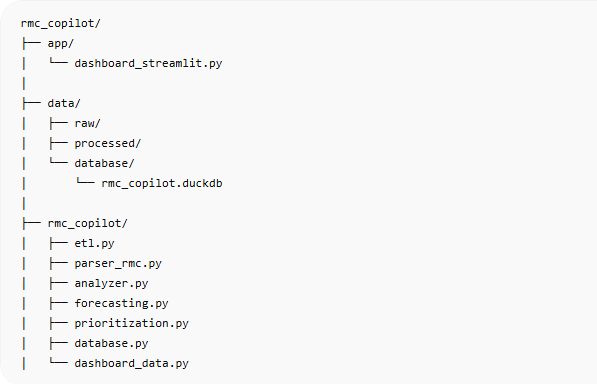

##### O dashboard v0.6 deve ter

1. KPIs principais
   - Total de VMs
   - P0
   - P1
   - Risco futuro 30d
   - Risco futuro 60d
   - Risco futuro 90d

2. Filtros
   - Cluster
   - Categoria da VM
   - Prioridade
   - Ação final
   - Risco futuro

3. Gráficos
   - Prioridade final
   - Ação final
   - Top clusters por P0/P1
   - Risco futuro 30/60/90
   - Top VMs por score
   - Memória p95 por cluster
   - Disco p95 por cluster

4. Tabelas interativas
   - P0
   - P1
   - Risco futuro
   - Otimização
   - Sem dados

5. Busca
   - Pesquisar VM
   - Pesquisar cluster

6. Resumo executivo automático

#### Caminho ideal

v0.5 — Excel visual  
status: concluído

v0.6 — Dashboard Streamlit local  
próximo passo

v0.7 — Persistência em DuckDB  
guardar histórico mensal

v0.8 — Comparação entre execuções  
mês atual x mês anterior

v0.9 — NLP local
perguntar: "quais clusters mais críticos?"  

v1.0 — RMC Copilot completo  
dashboard + motor + NLP + histórico

O Excel continua apenas como exportação opcional. O produto de verdade será o dashboard.

Vamos montar o v0.6 como dashboard local em Streamlit. A ideia é reaproveitar df_analise_v4 e resumo_cluster_v04, mas transformar isso em tela interativa com filtros, KPIs, gráficos e tabelas.

Vamos criar o **RMC Copilot v0.6 — Dashboard Web Local com Streamlit.**

Nesta versão, o Excel deixa de ser o centro. Ele vira só exportação opcional.

#### Instalar dependências

```bash
pip install streamlit plotly
```
Caso queira garantir outras bibliotecas

```bash
pip install pandas numpy openpyxl scikit-learn plotly streamlit
```

Crie a pasta app na raiza do projeto

A estrutura ficará assim:

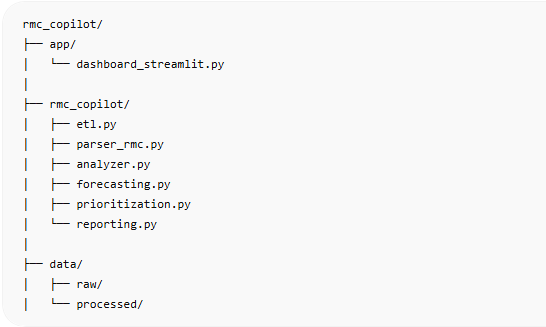

Criar o arquivo do dashboard

app/dashboard_streamlit.py

In [72]:
from pathlib import Path

from rmc_copilot.database import salvar_execucao, listar_execucoes

caminho_banco = PROJECT_ROOT / "data/database/rmc_copilot.duckdb"

execution_id = salvar_execucao(
    caminho_banco=caminho_banco,
    df_analise_v4=df_analise_v4,
    resumo_cluster_v04=resumo_cluster_v04,
    nome_arquivo="RMC_Recursos_VM_v5_10_2_20260610_094958.xlsx",
    observacao="Primeira carga v0.7"
)

execution_id

'RMC_Recursos_VM_v5_10_2_20260610_094958_20260611_215842'

In [73]:
listar_execucoes(caminho_banco)

,execution_id,nome_arquivo,data_execucao,total_vms,observacao
0,RMC_Recursos_VM_v5_10_2_20260610_094958_202606...,RMC_Recursos_VM_v5_10_2_20260610_094958.xlsx,2026-06-11 21:58:42.224007,2368,Primeira carga v0.7


In [75]:
from rmc_copilot.database import (
    carregar_analise_por_execucao,
    carregar_resumo_cluster_por_execucao,
)

df_banco = carregar_analise_por_execucao(
    caminho_banco=caminho_banco,
    execution_id=execution_id
)

resumo_cluster_banco = carregar_resumo_cluster_por_execucao(
    caminho_banco=caminho_banco,
    execution_id=execution_id
)

df_banco.shape, resumo_cluster_banco.shape

((2368, 33), (11, 27))